In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)
import numpy as np
import seaborn as sns

In [2]:
# Read in PPI table and K562 gloassary data

glossary_k562 = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/K562_global_SHAP_Signed-Local-SHAP-Mean-Bound-Only.tsv', sep='\t')
glossary_hepg2 = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/HepG2_global_SHAP_Signed-Local-SHAP-Mean-Bound-Only.tsv', sep='\t')
ppi = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/PPI_table_k562.csv')
ppi2 = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/PPI_table_hepg2.csv')

## K562

In [3]:
# Shrink the PPI table
ppi_df = ppi[["Bait", "Prey"]]

# Make each row (position) from the glossary table into its own 1x140 df
row_dfs = [glossary_k562.iloc[i:i+1, :] for i in range(len(glossary_k562))]
print(row_dfs[0].shape)  # (1, 140)

(1, 140)


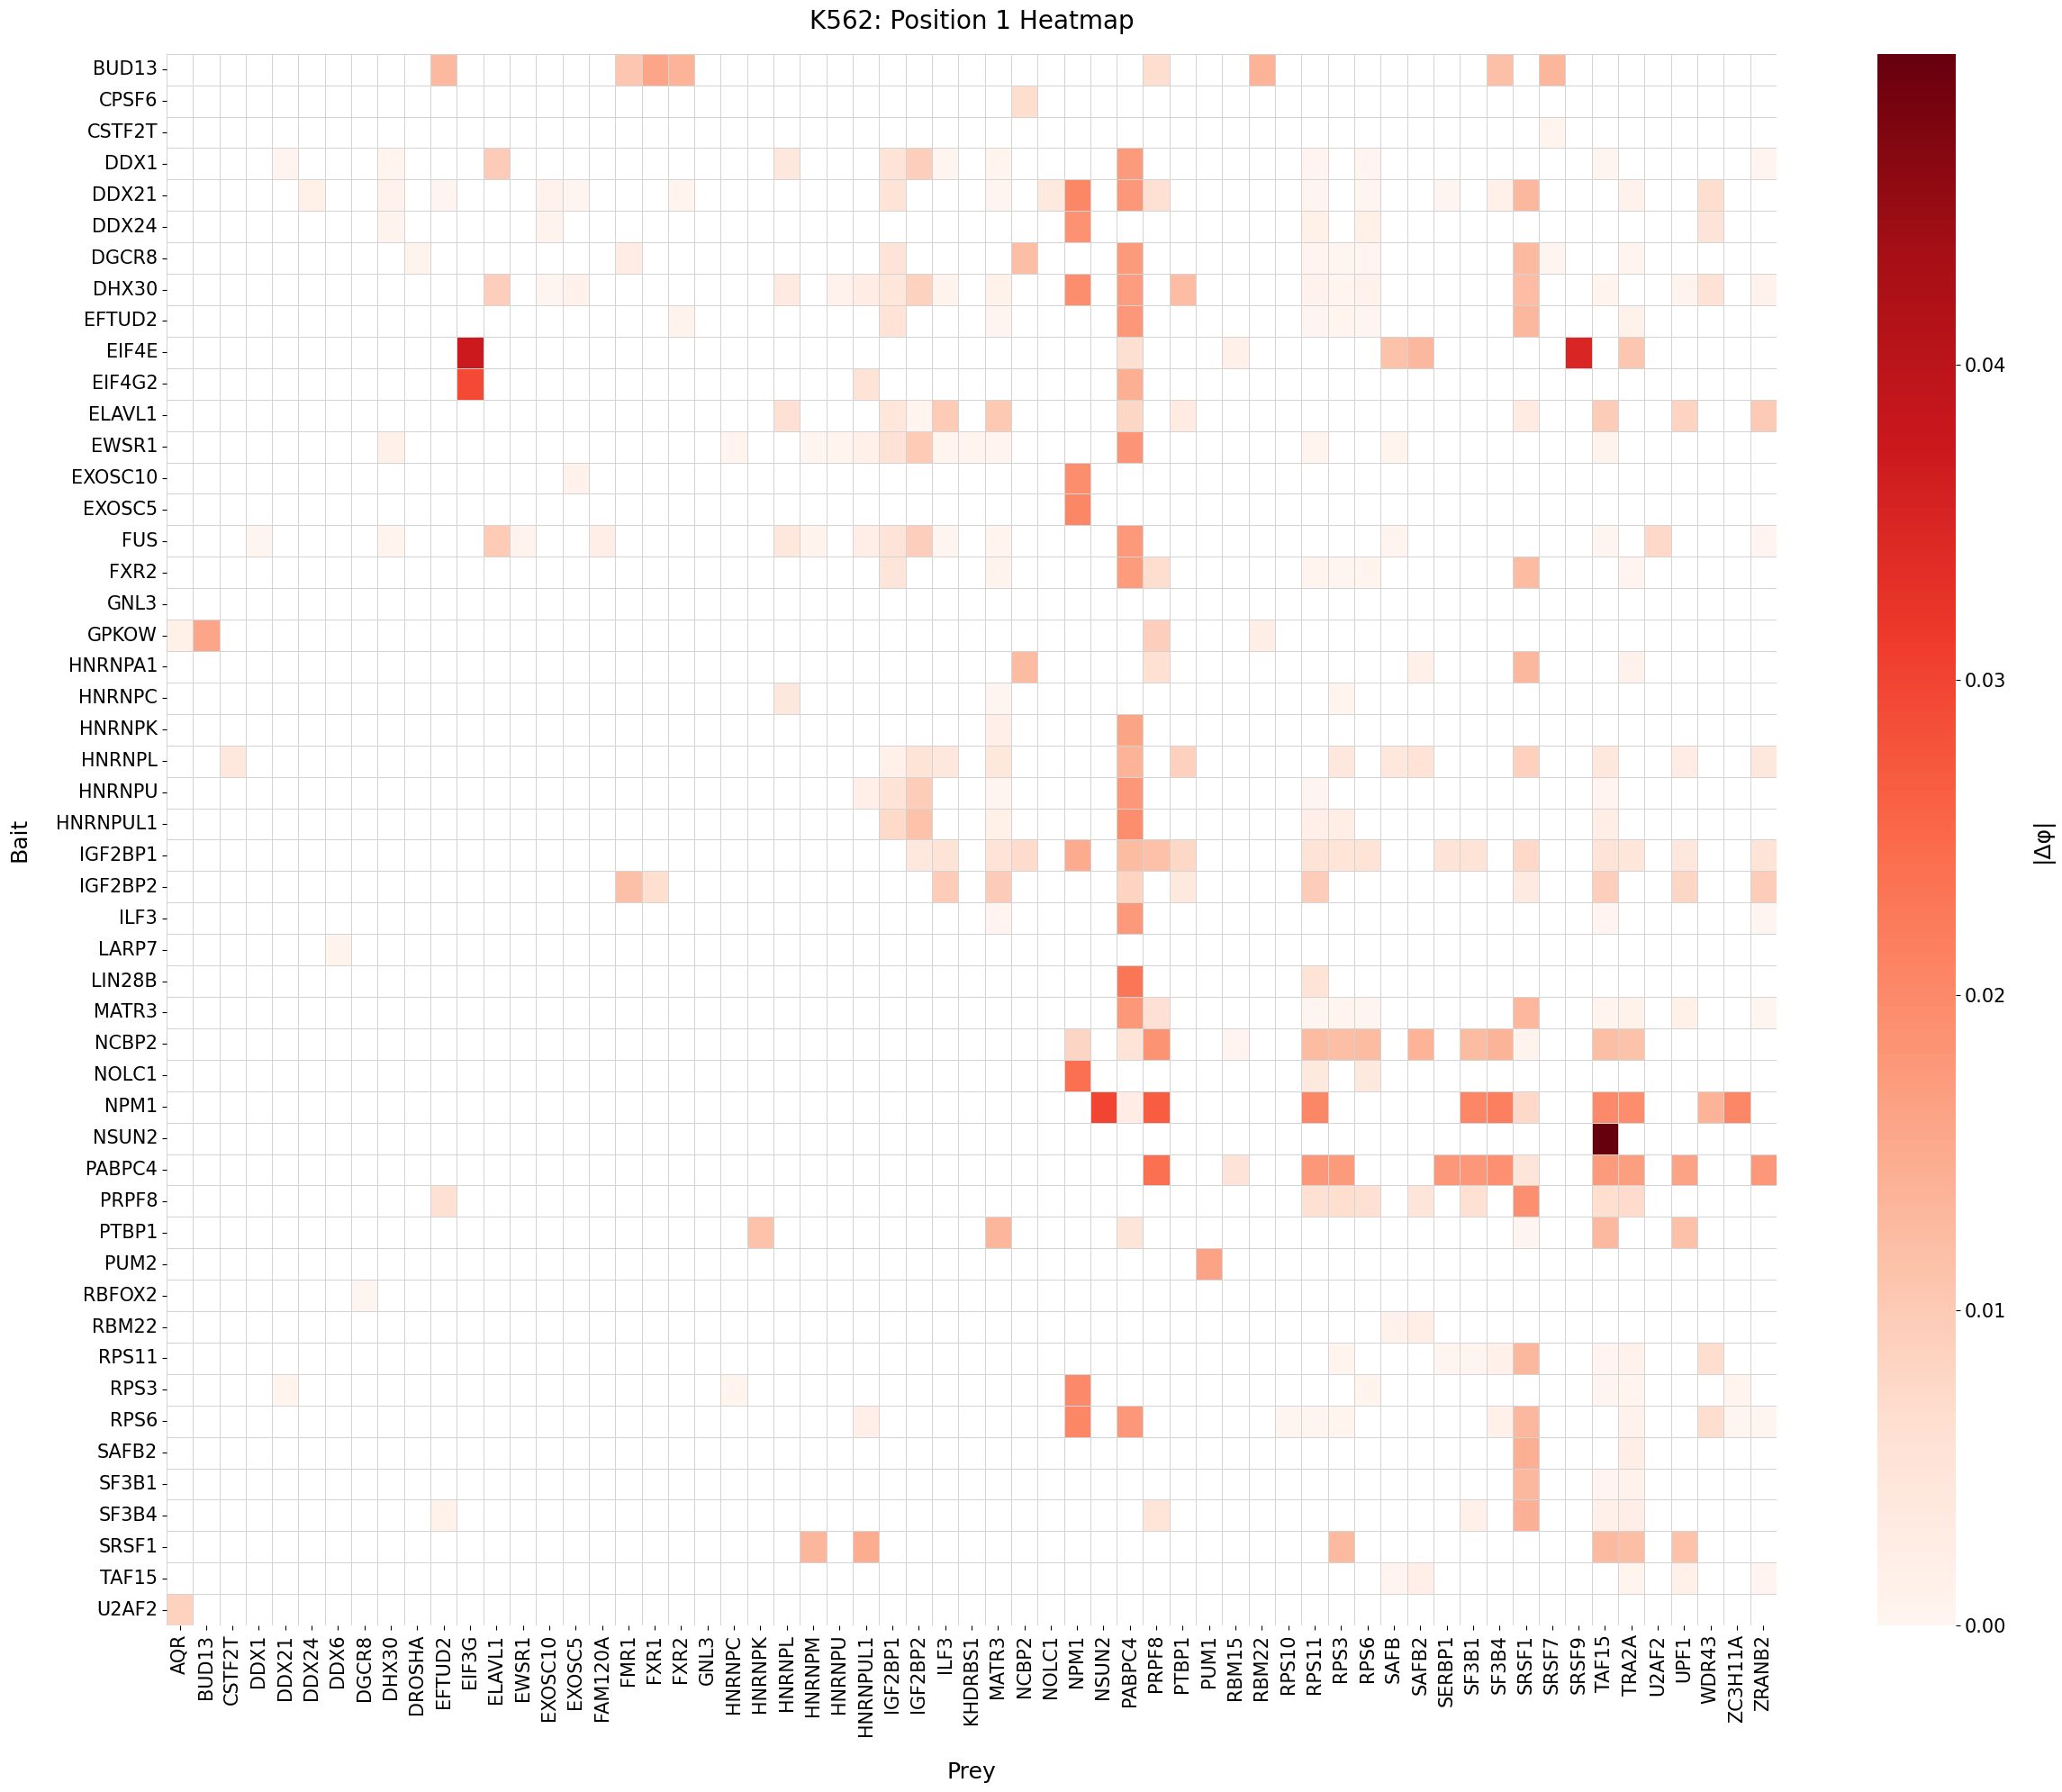

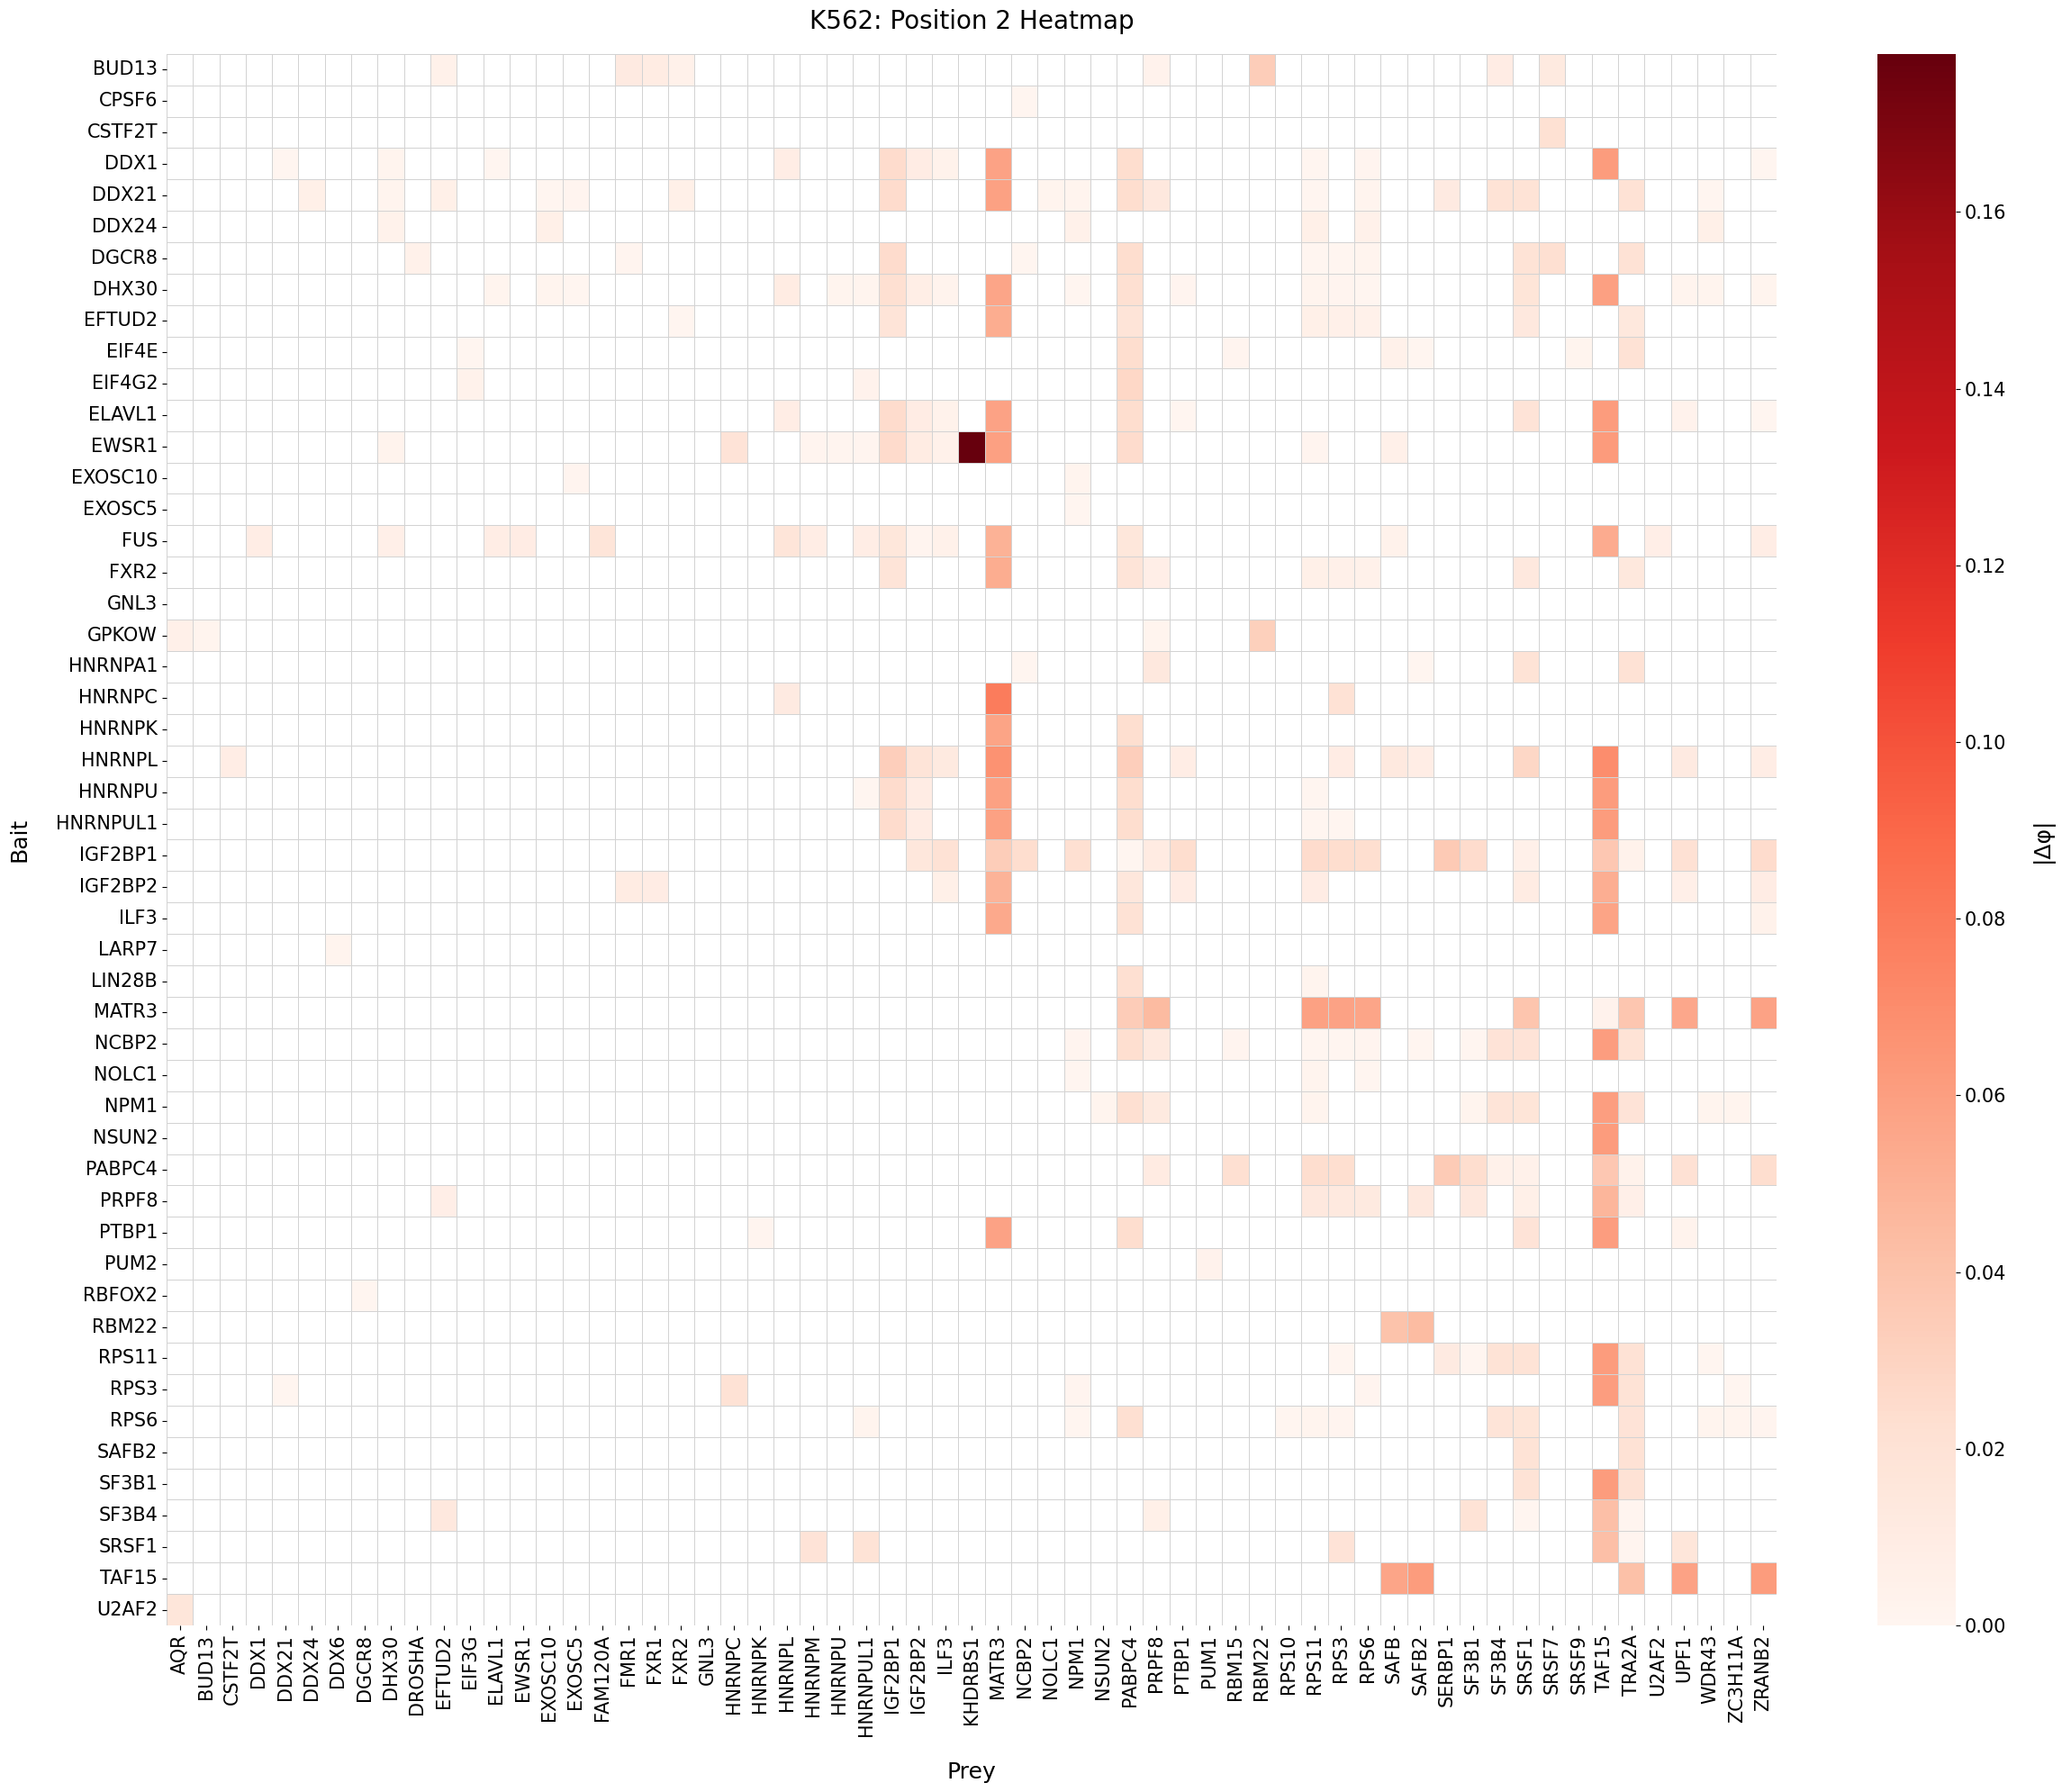

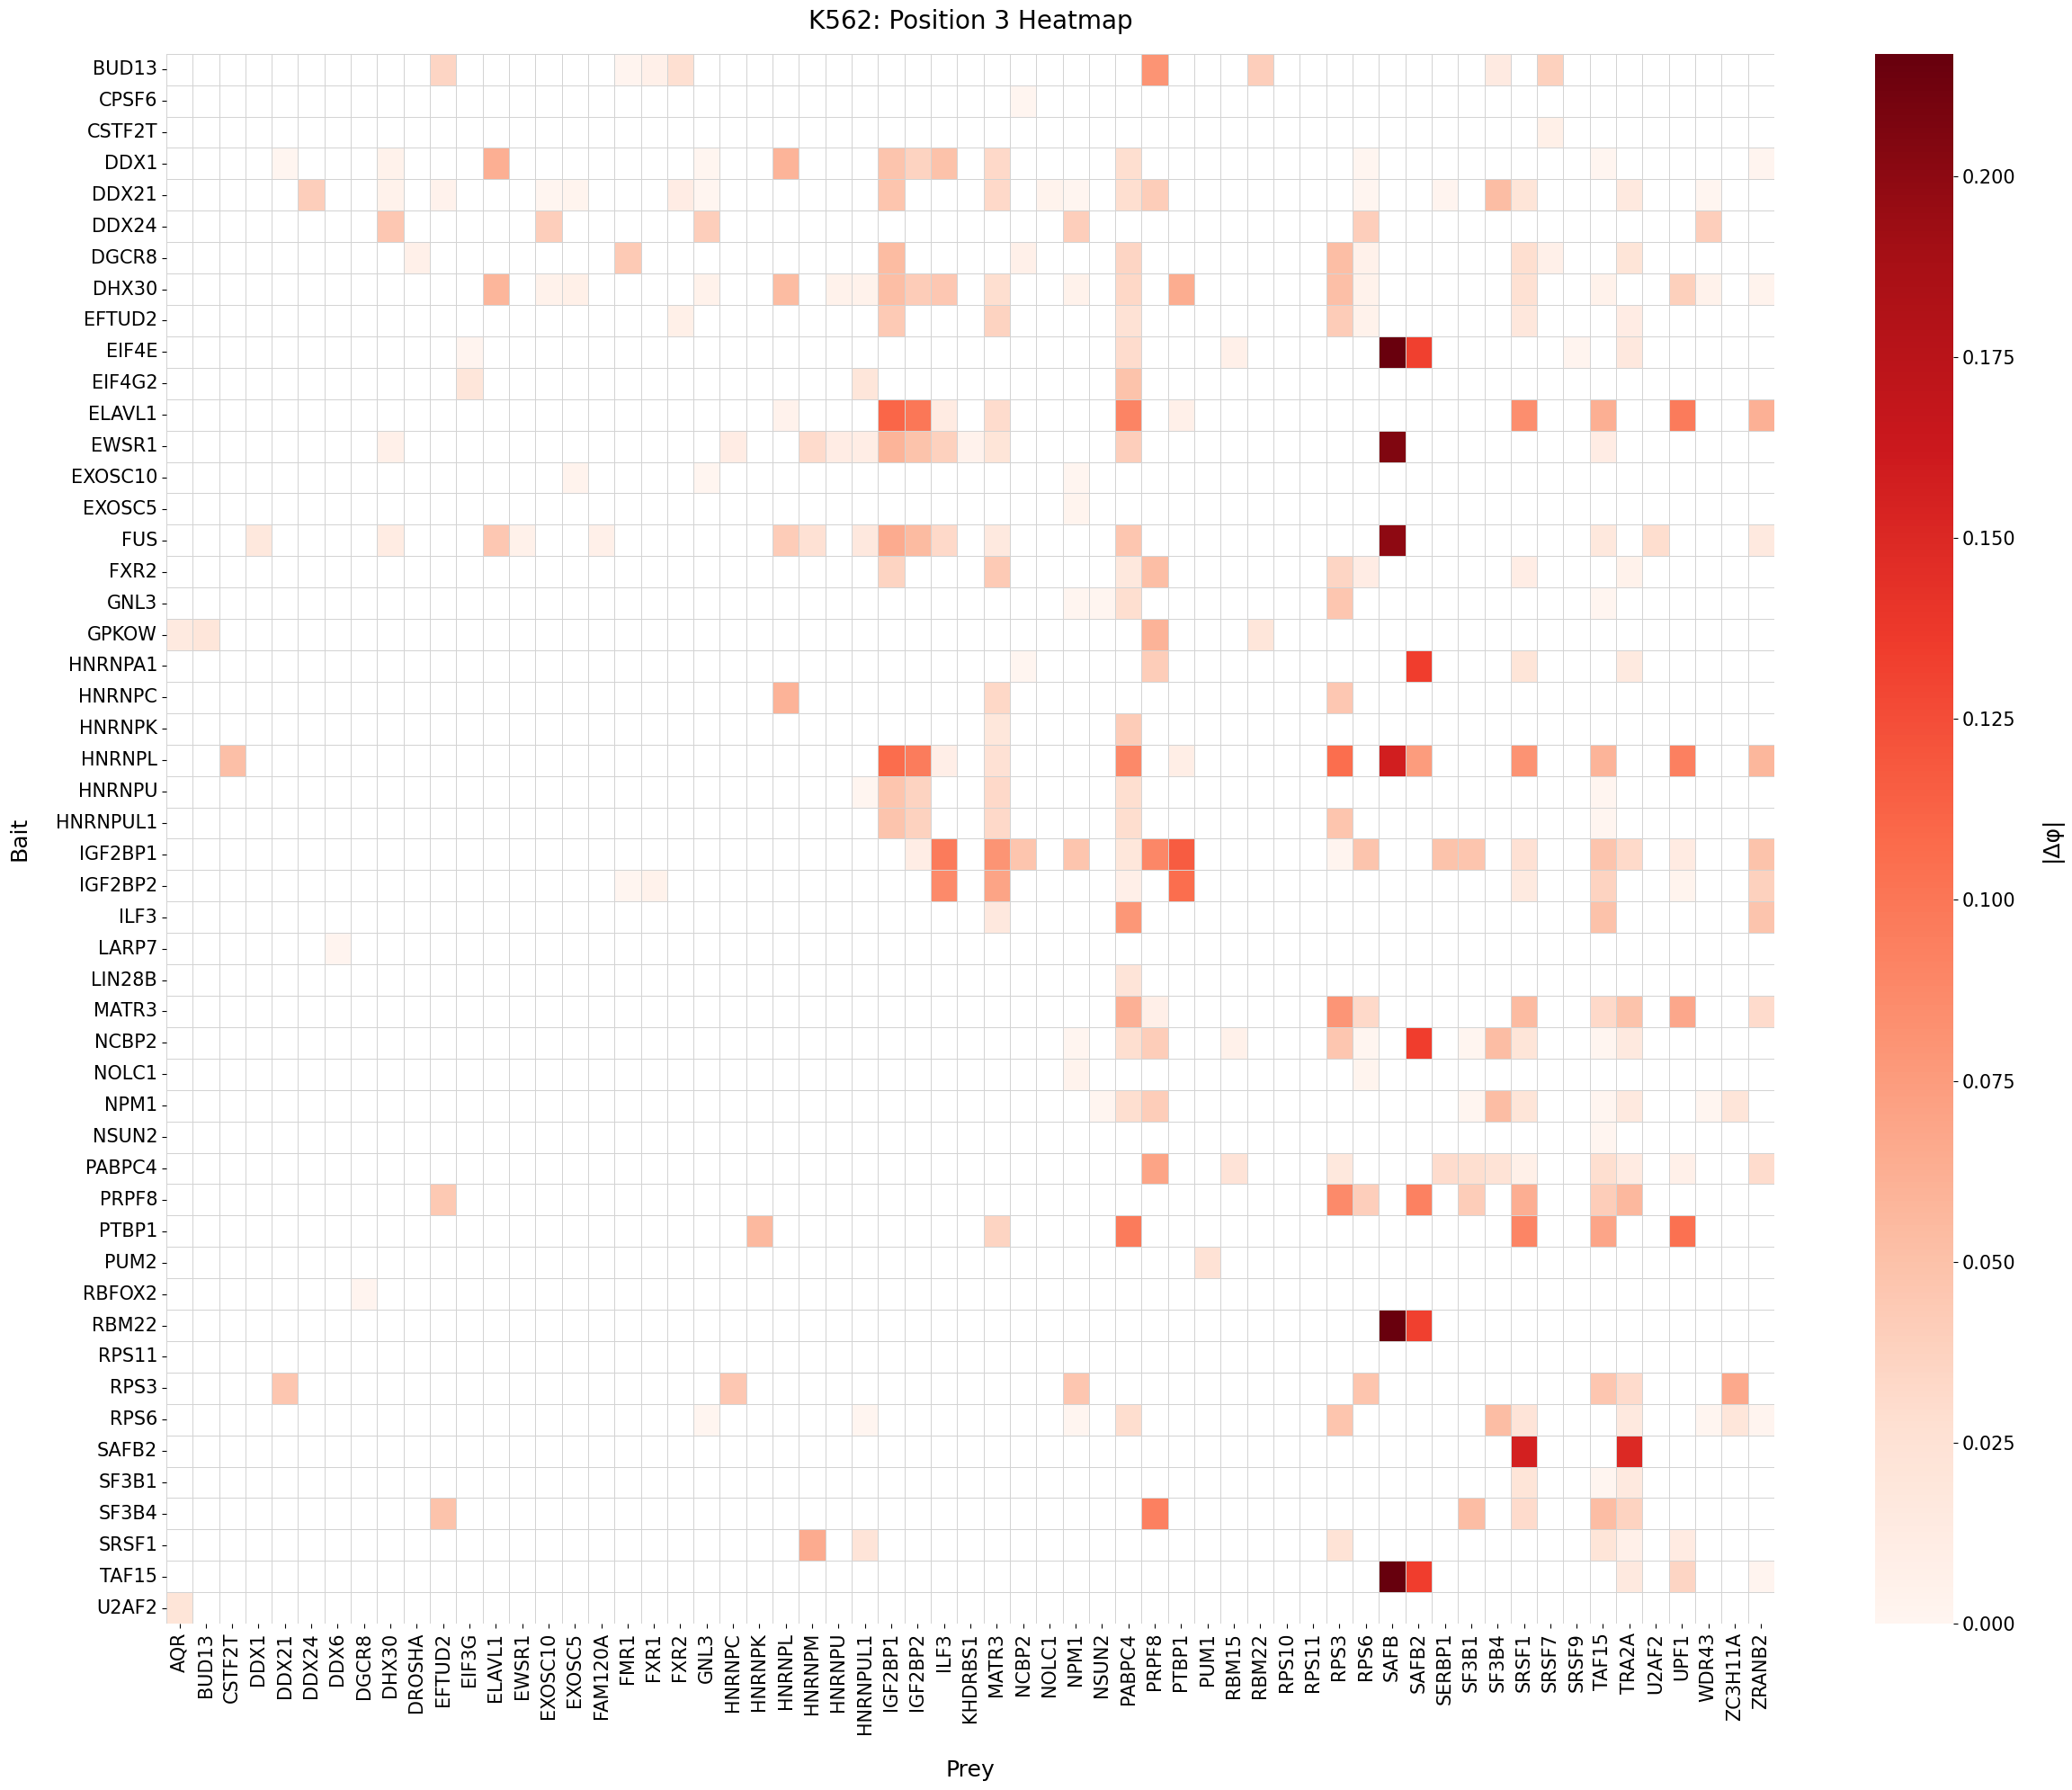

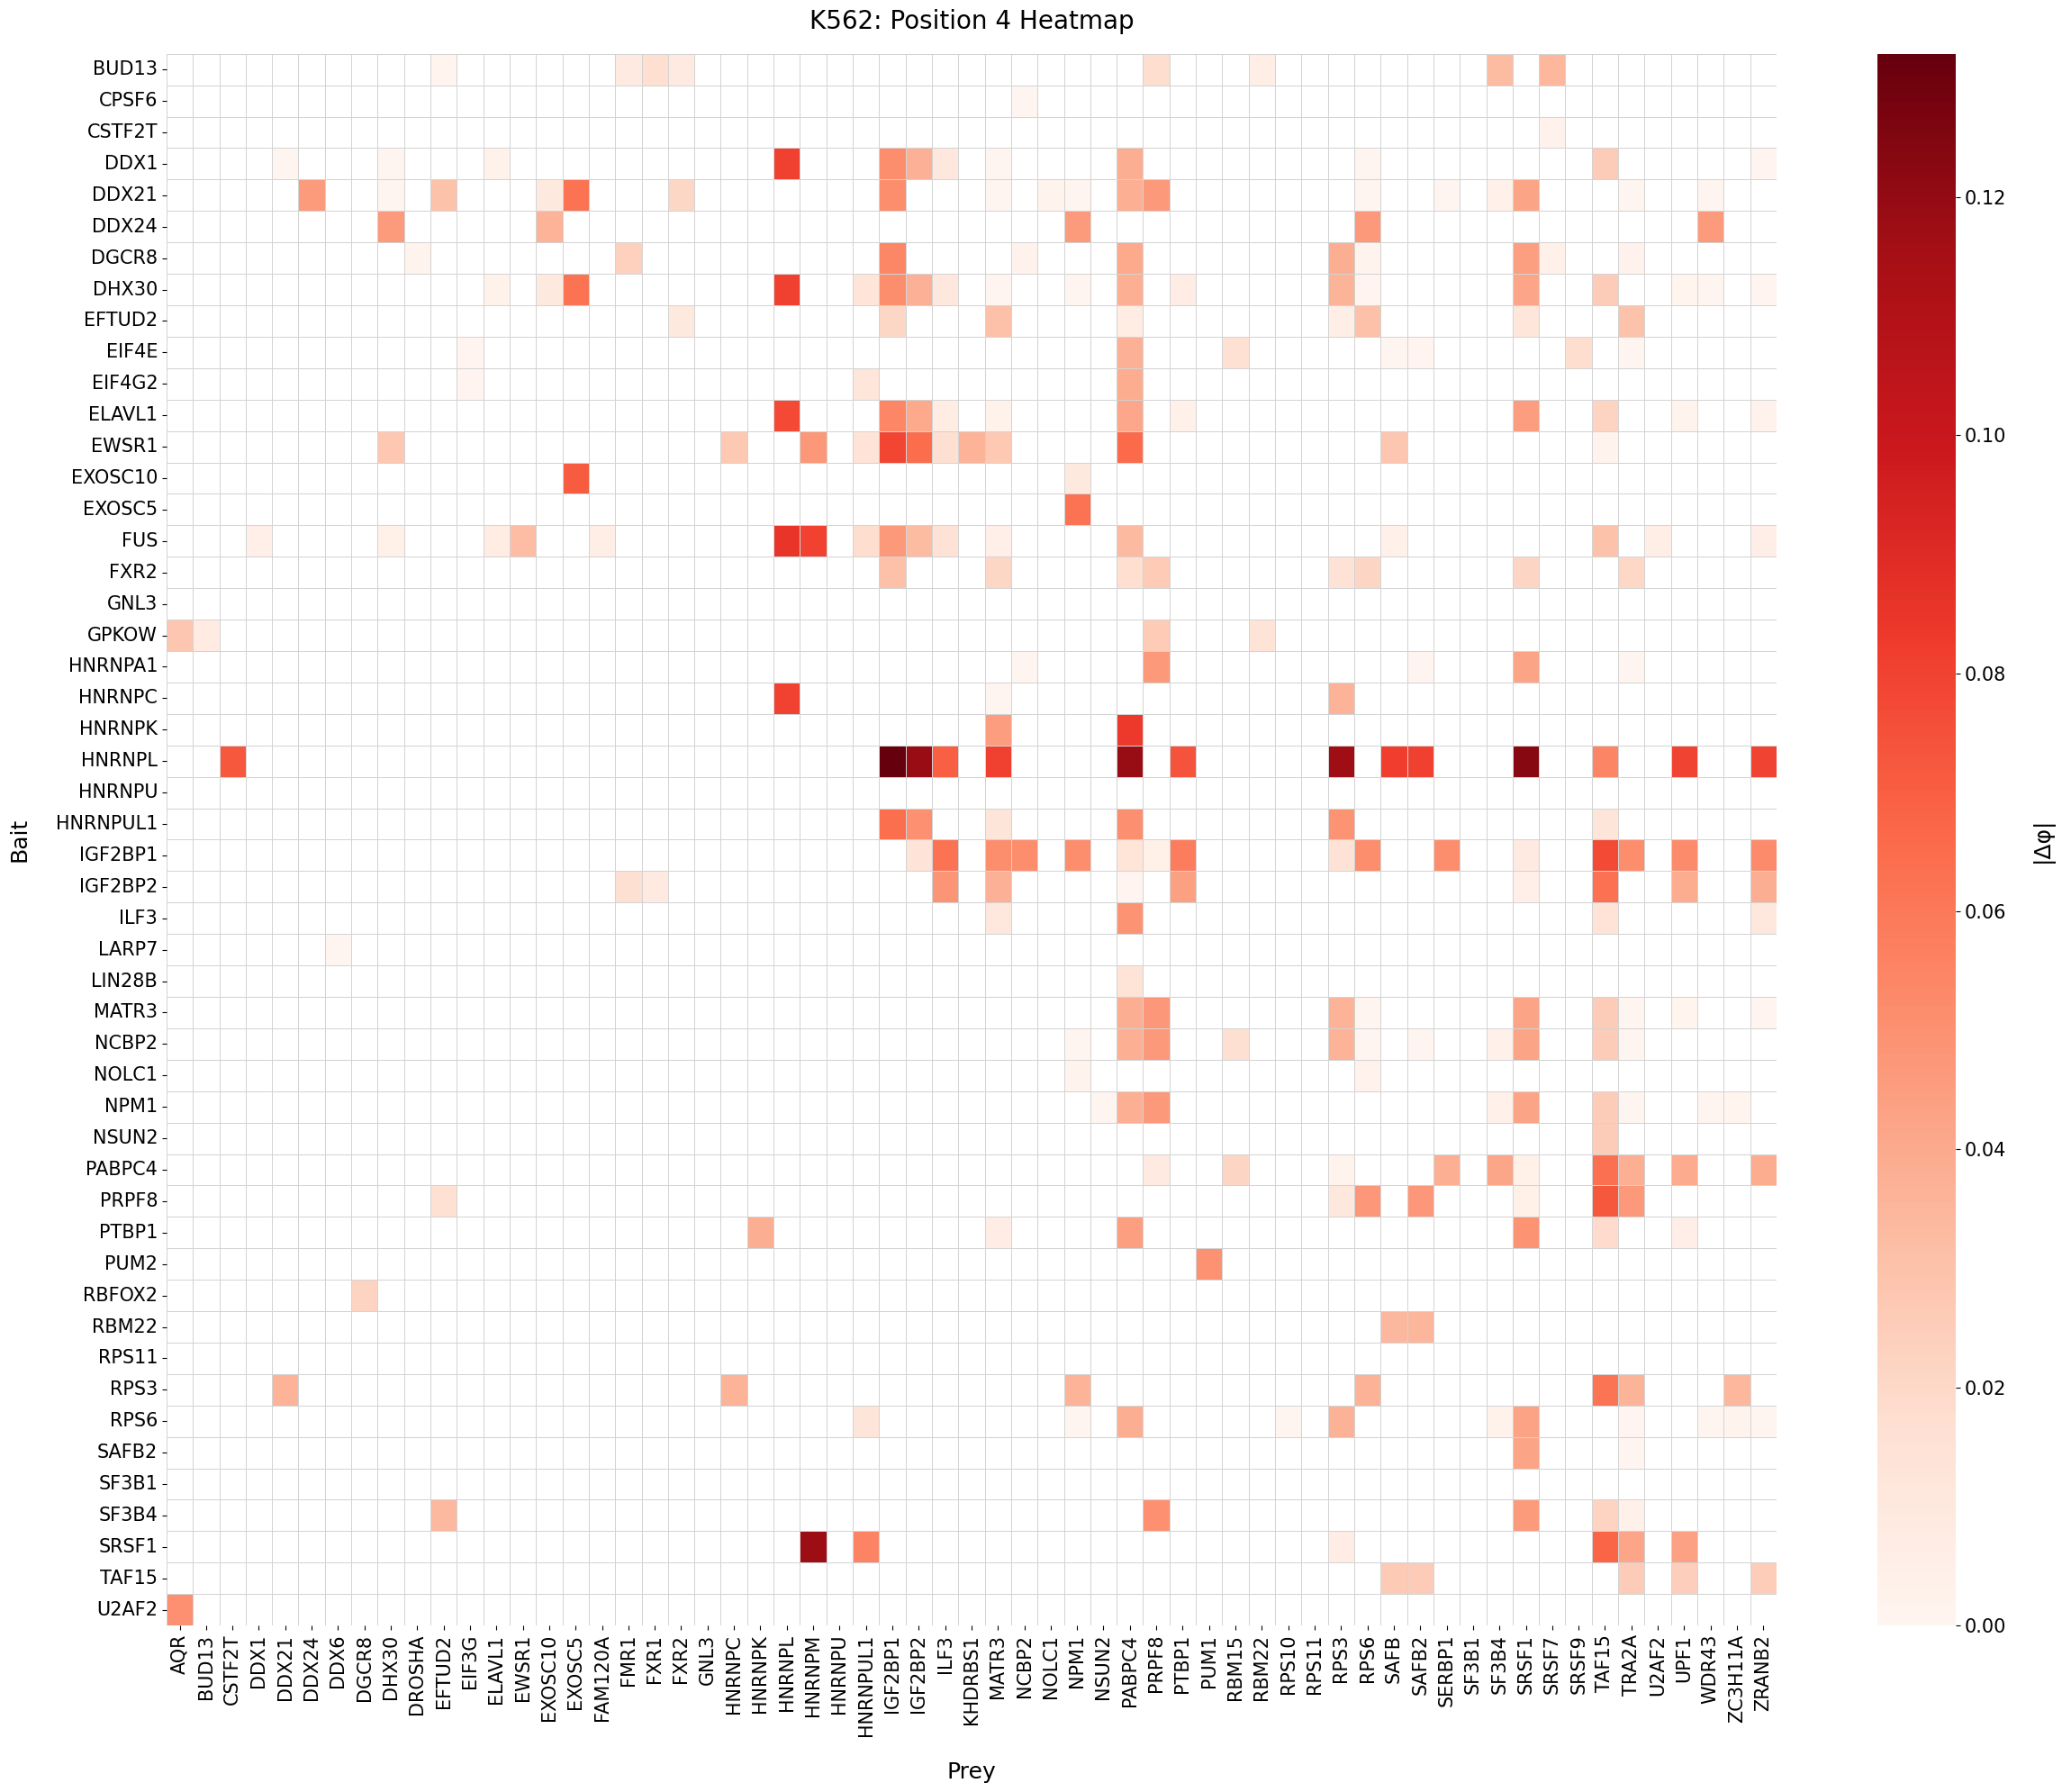

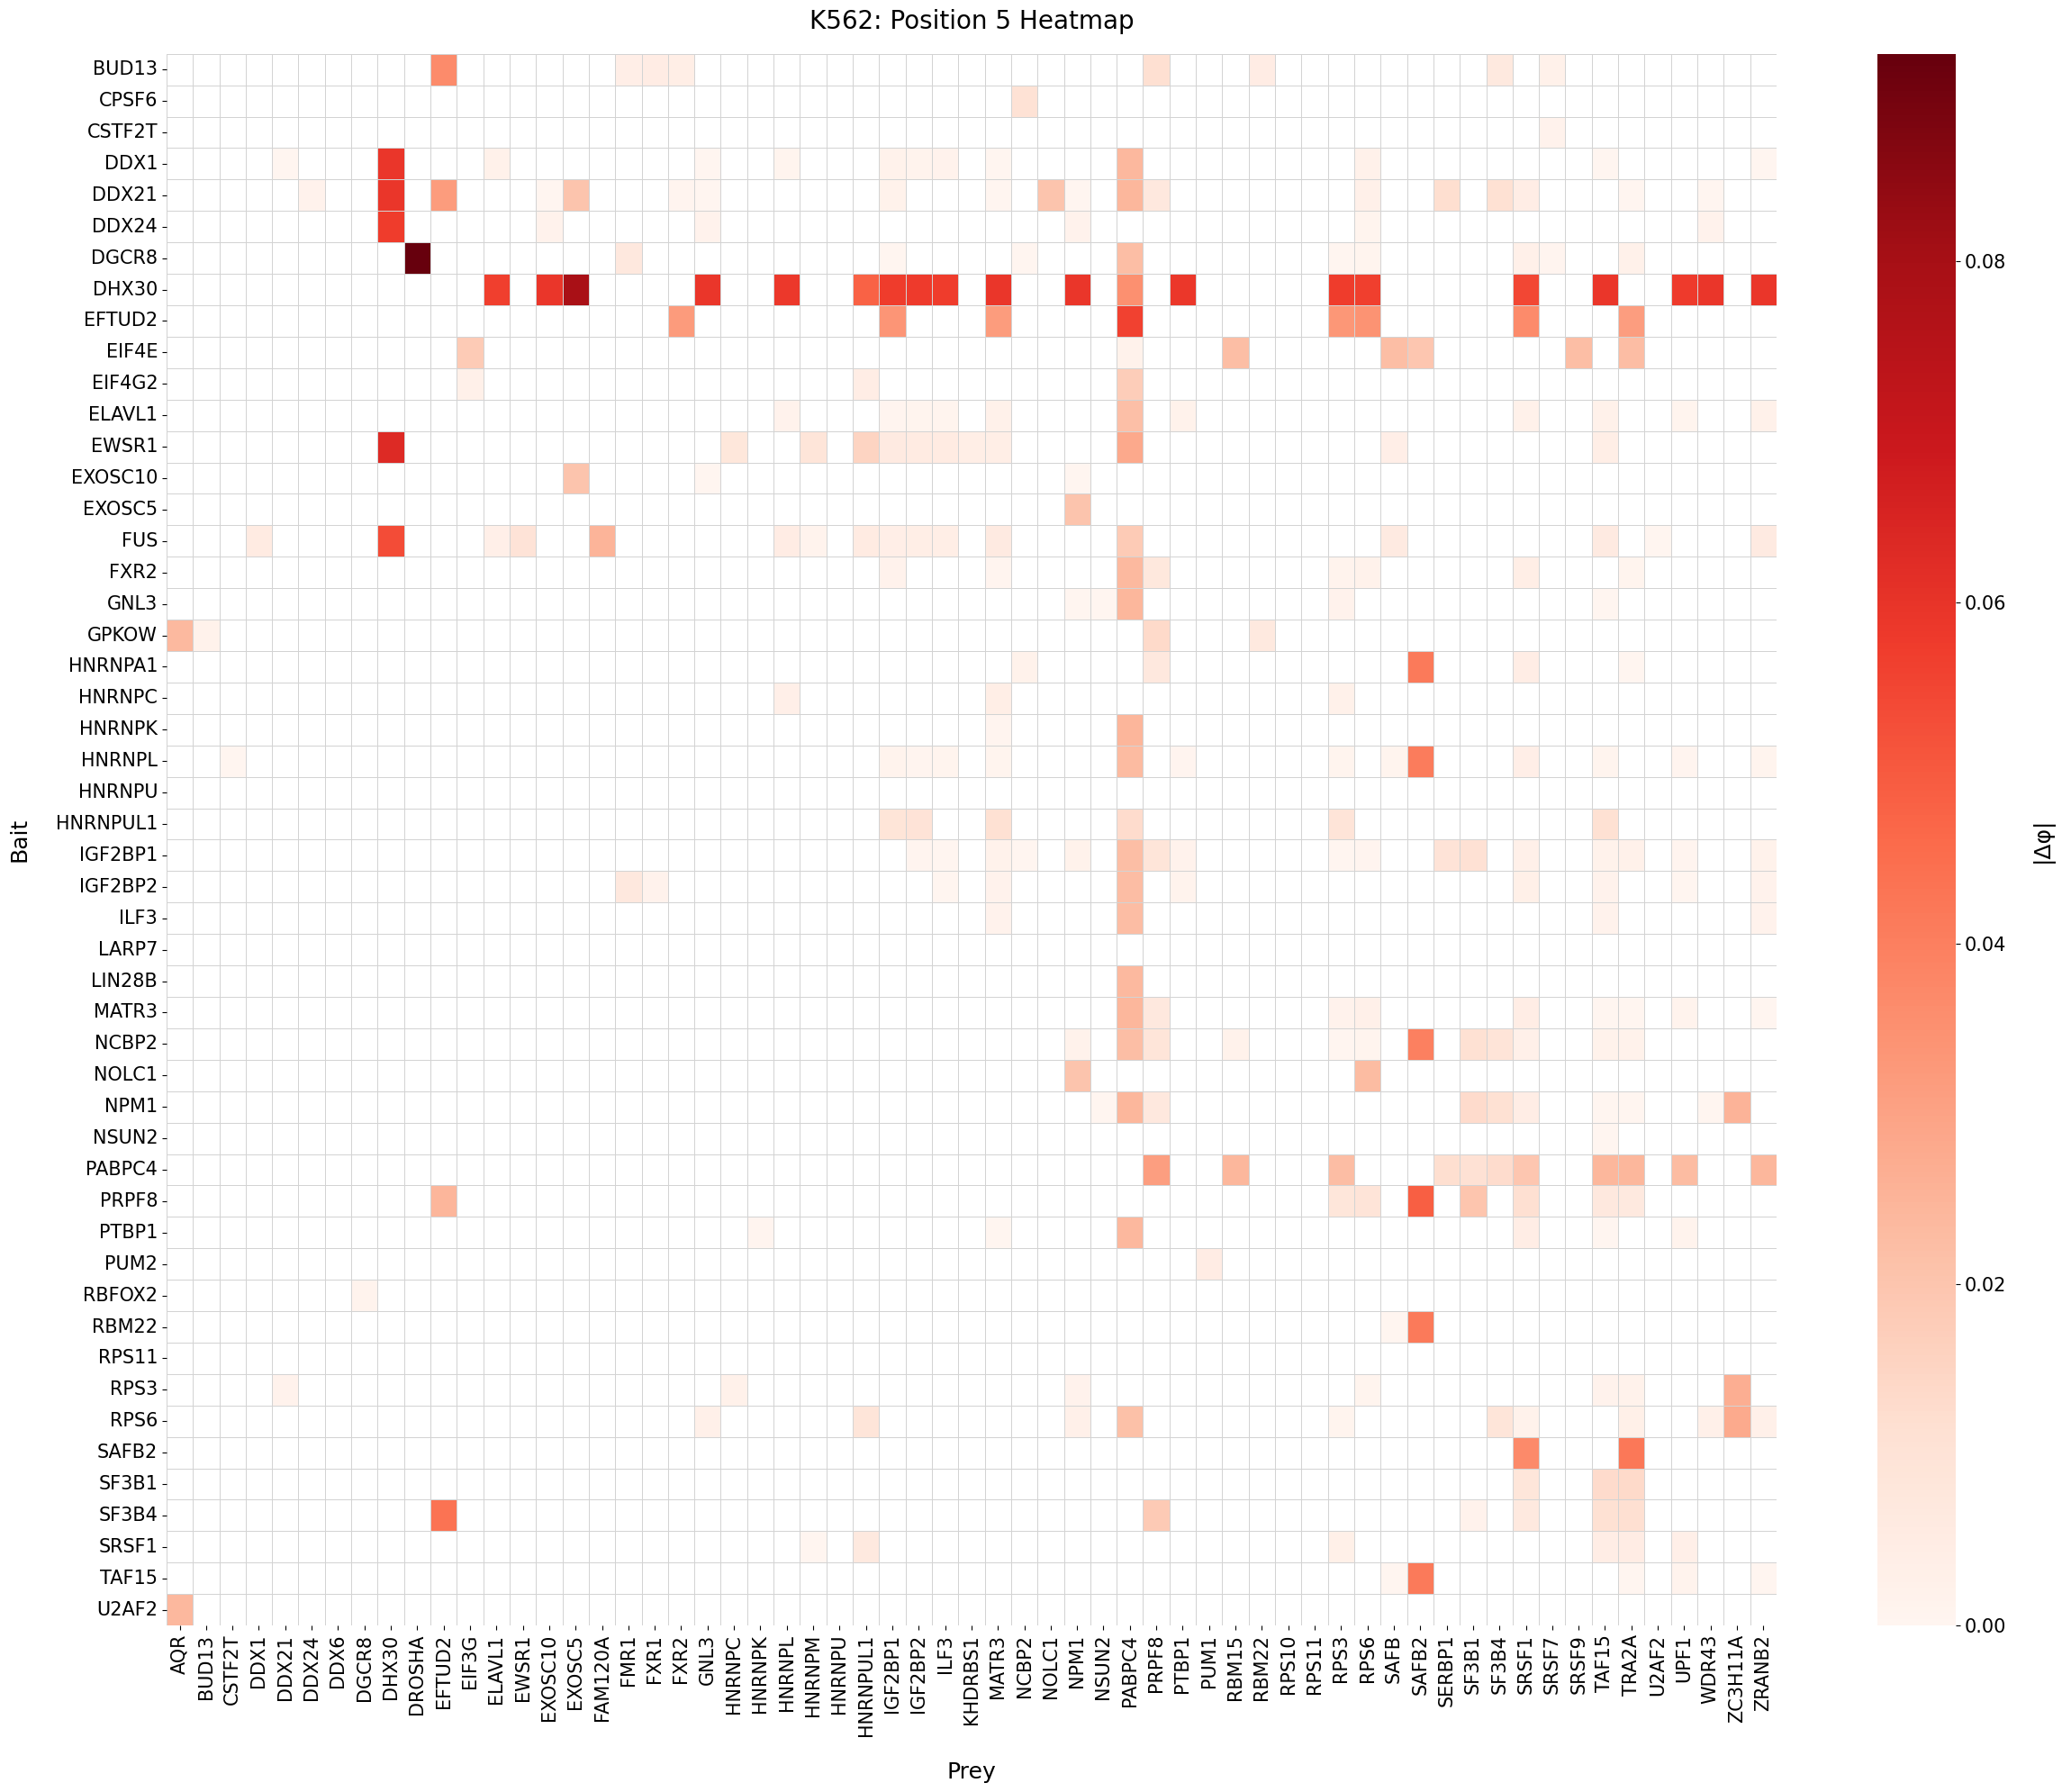

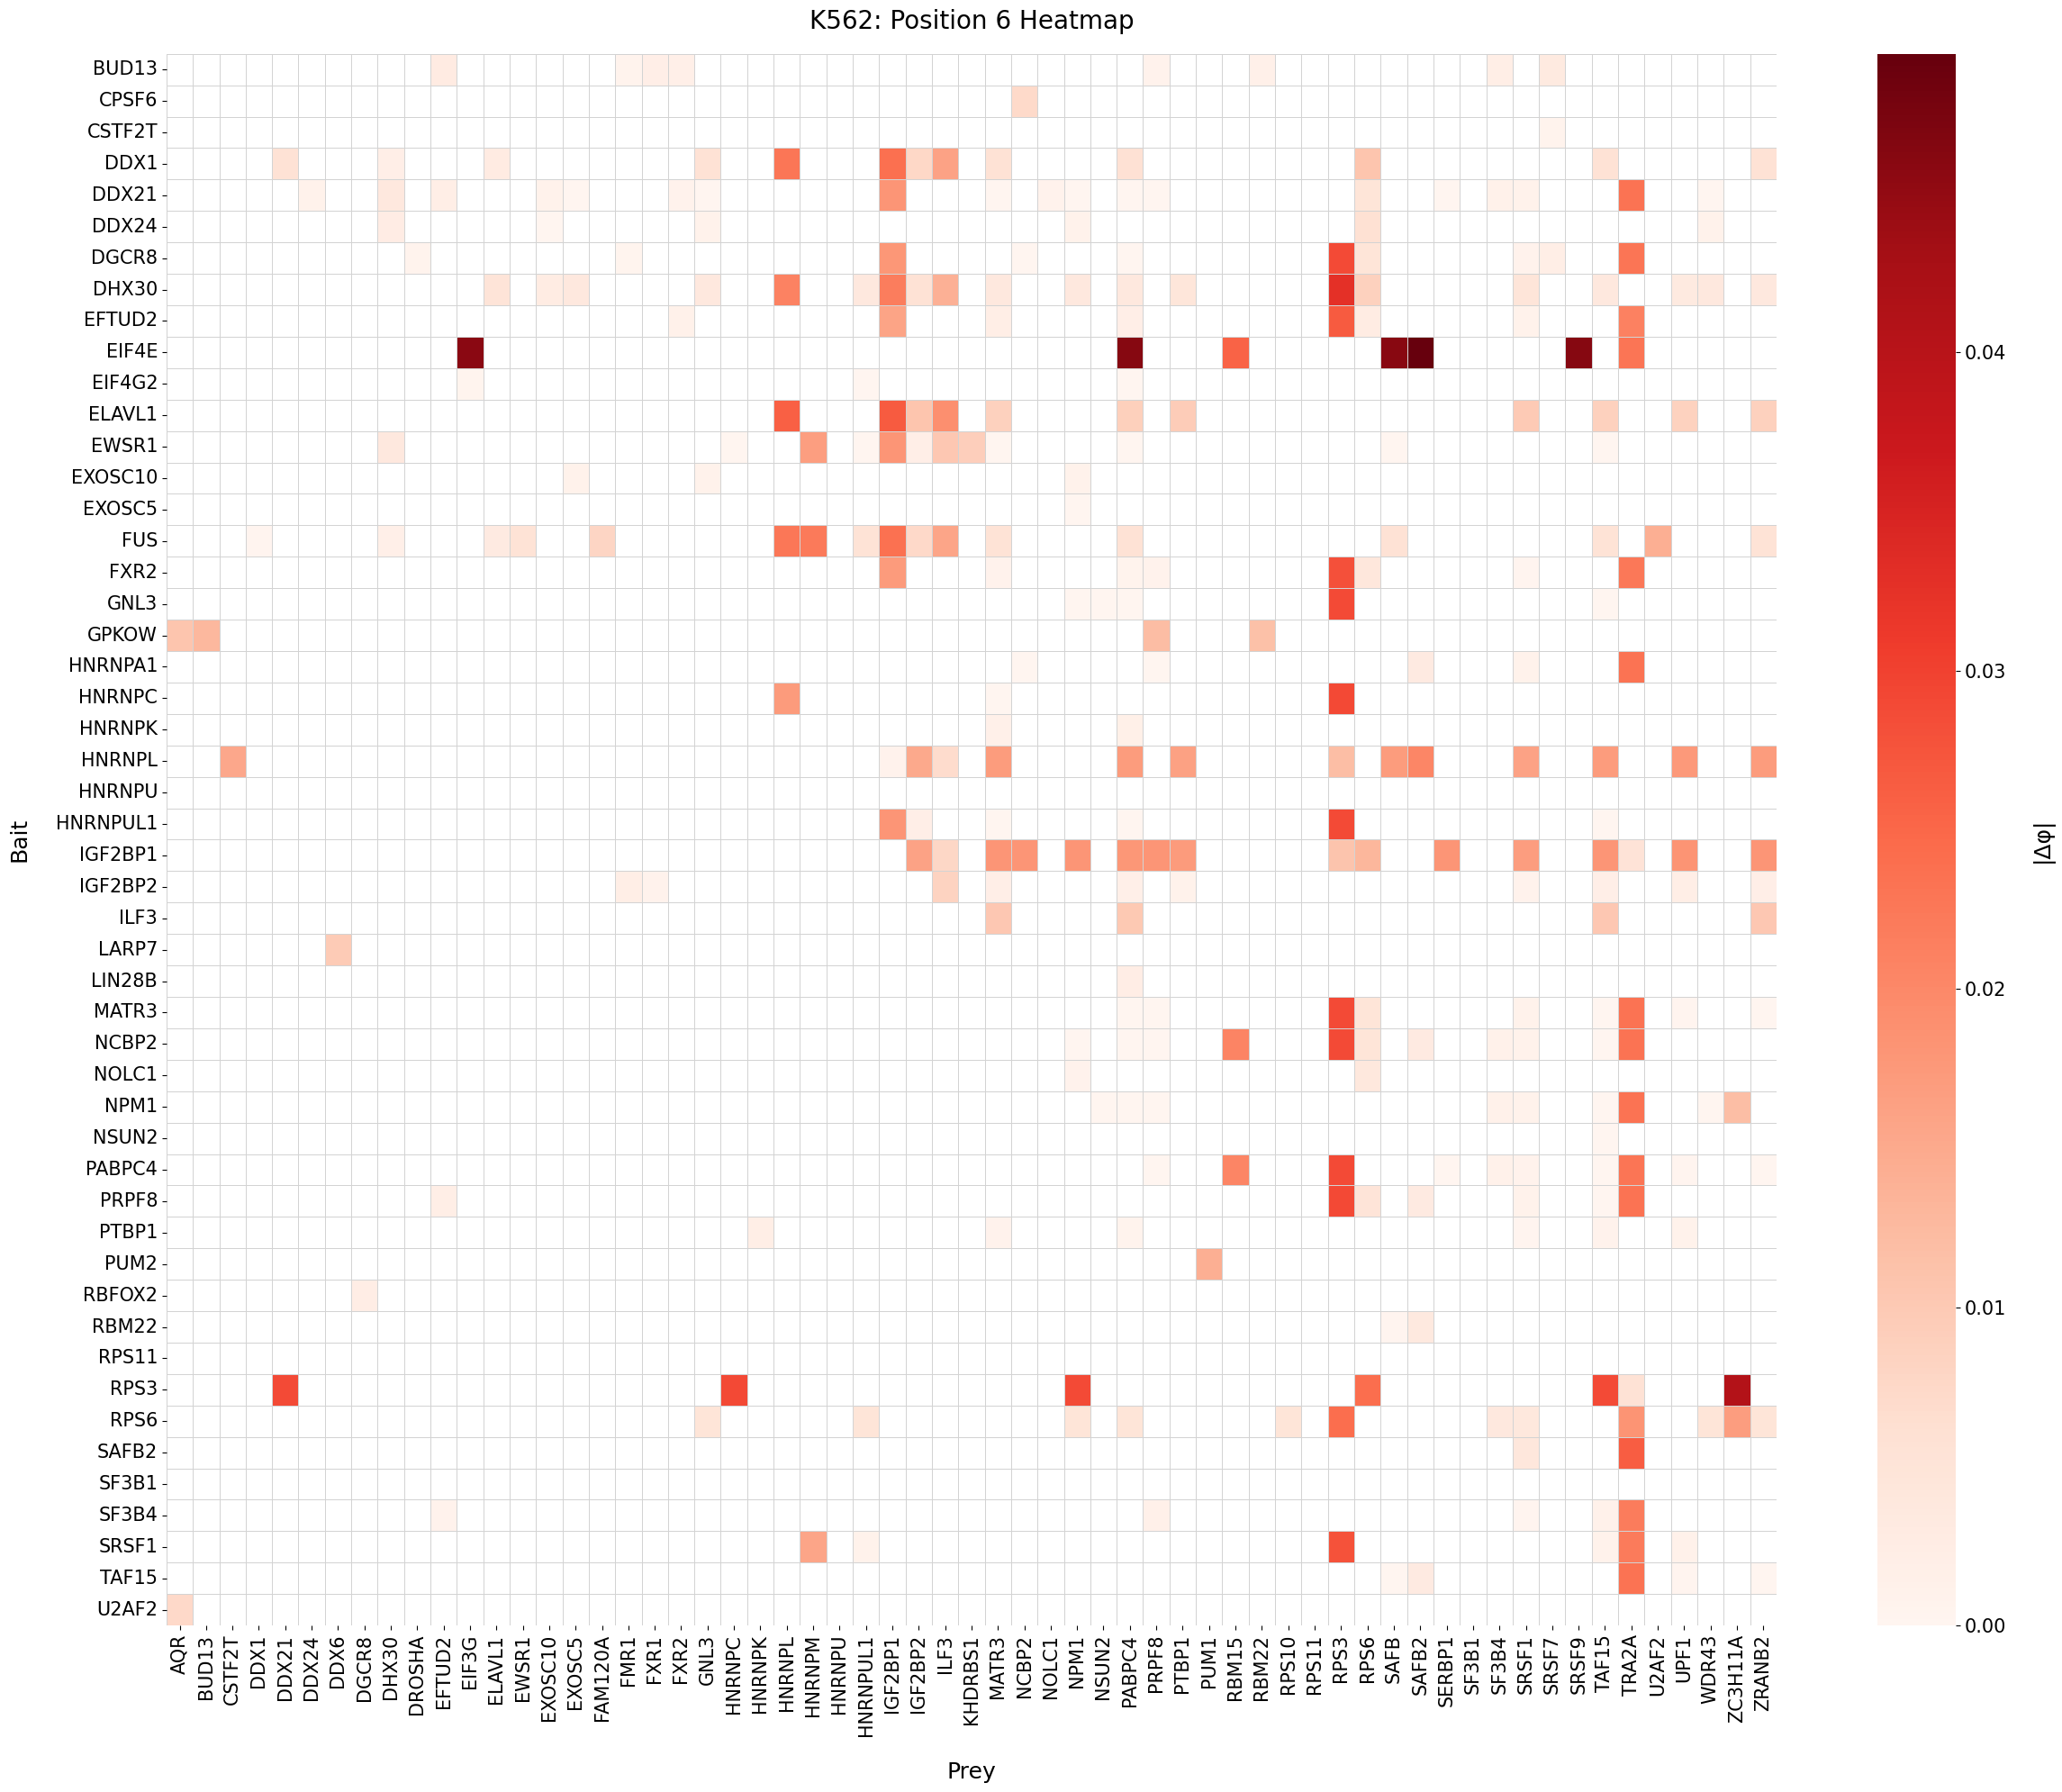

In [5]:
for i, each in enumerate(row_dfs):
    # turn df into dict
    shap_dict = each.iloc[0].to_dict()  # {protein_name: shap_value}
    ppi_df_plot = ppi_df.copy()
    
    # Compute absolute difference
    ppi_df_plot['delta_shap'] = ppi_df_plot.apply(
        lambda row: abs(shap_dict[row['Bait']] - shap_dict[row['Prey']]), 
        axis=1)
    
    # Pivot into matrix (Prey = X, Bait = Y)
    heatmap_data = ppi_df_plot.pivot(index="Bait", columns="Prey", values="delta_shap")
    
    # Make figure scale with matrix size
    plt.figure(figsize=(len(heatmap_data.columns) * 0.4, len(heatmap_data.index) * 0.4))

    ax = sns.heatmap(
        heatmap_data,
        cmap="Reds",
        cbar_kws={"label": r"|Δφ|"},  # phi symbol
        linewidths=0.5,
        linecolor="lightgray",
        square=False,
        mask=heatmap_data.isna()  # keep NaN cells white
    )

    # Get colorbar and format its label/ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)          # tick labels
    cbar.ax.set_ylabel(r"|Δφ|", fontsize=18, labelpad=20)  # label

    # Axis labels with font size and labelpad
    plt.xlabel("Prey", fontsize=18, labelpad=20)
    plt.ylabel("Bait", fontsize=18, labelpad=20)

    # Tick labels
    plt.xticks(rotation=90, fontsize=15)
    plt.yticks(rotation=0, fontsize=15)

    # Title
    plt.title(f"K562: Position {i+1} Heatmap", fontsize=20, pad=20)

    plt.tight_layout()
    plt.show()


## HepG2

In [6]:
ppi_df = ppi2[["Bait", "Prey"]]

# Make each row (position) from the glossary table into its own 1x106 df
row_dfs2 = [glossary_hepg2.iloc[i:i+1, :] for i in range(len(glossary_hepg2))]
print(row_dfs2[0].shape)  # (1, 106)

(1, 106)


In [7]:
print("Row_dfs2[0] columns:", row_dfs2[0].columns)
print("PPI df columns:", ppi_df.columns)
print("Example shap_dict keys:", list(row_dfs2[0].iloc[0].to_dict().keys())[:10])



Row_dfs2[0] columns: Index(['Position', 'AGGF1', 'AKAP1', 'AQR', 'BCCIP', 'BCLAF1', 'BUD13',
       'CDC40', 'CSTF2', 'CSTF2T',
       ...
       'UCHL5', 'UPF1', 'UTP18', 'WDR43', 'XPO5', 'XRCC6', 'XRN2', 'YBX3',
       'ZC3H11A', 'ZNF800'],
      dtype='object', length=106)
PPI df columns: Index(['Bait', 'Prey'], dtype='object')
Example shap_dict keys: ['Position', 'AGGF1', 'AKAP1', 'AQR', 'BCCIP', 'BCLAF1', 'BUD13', 'CDC40', 'CSTF2', 'CSTF2T']


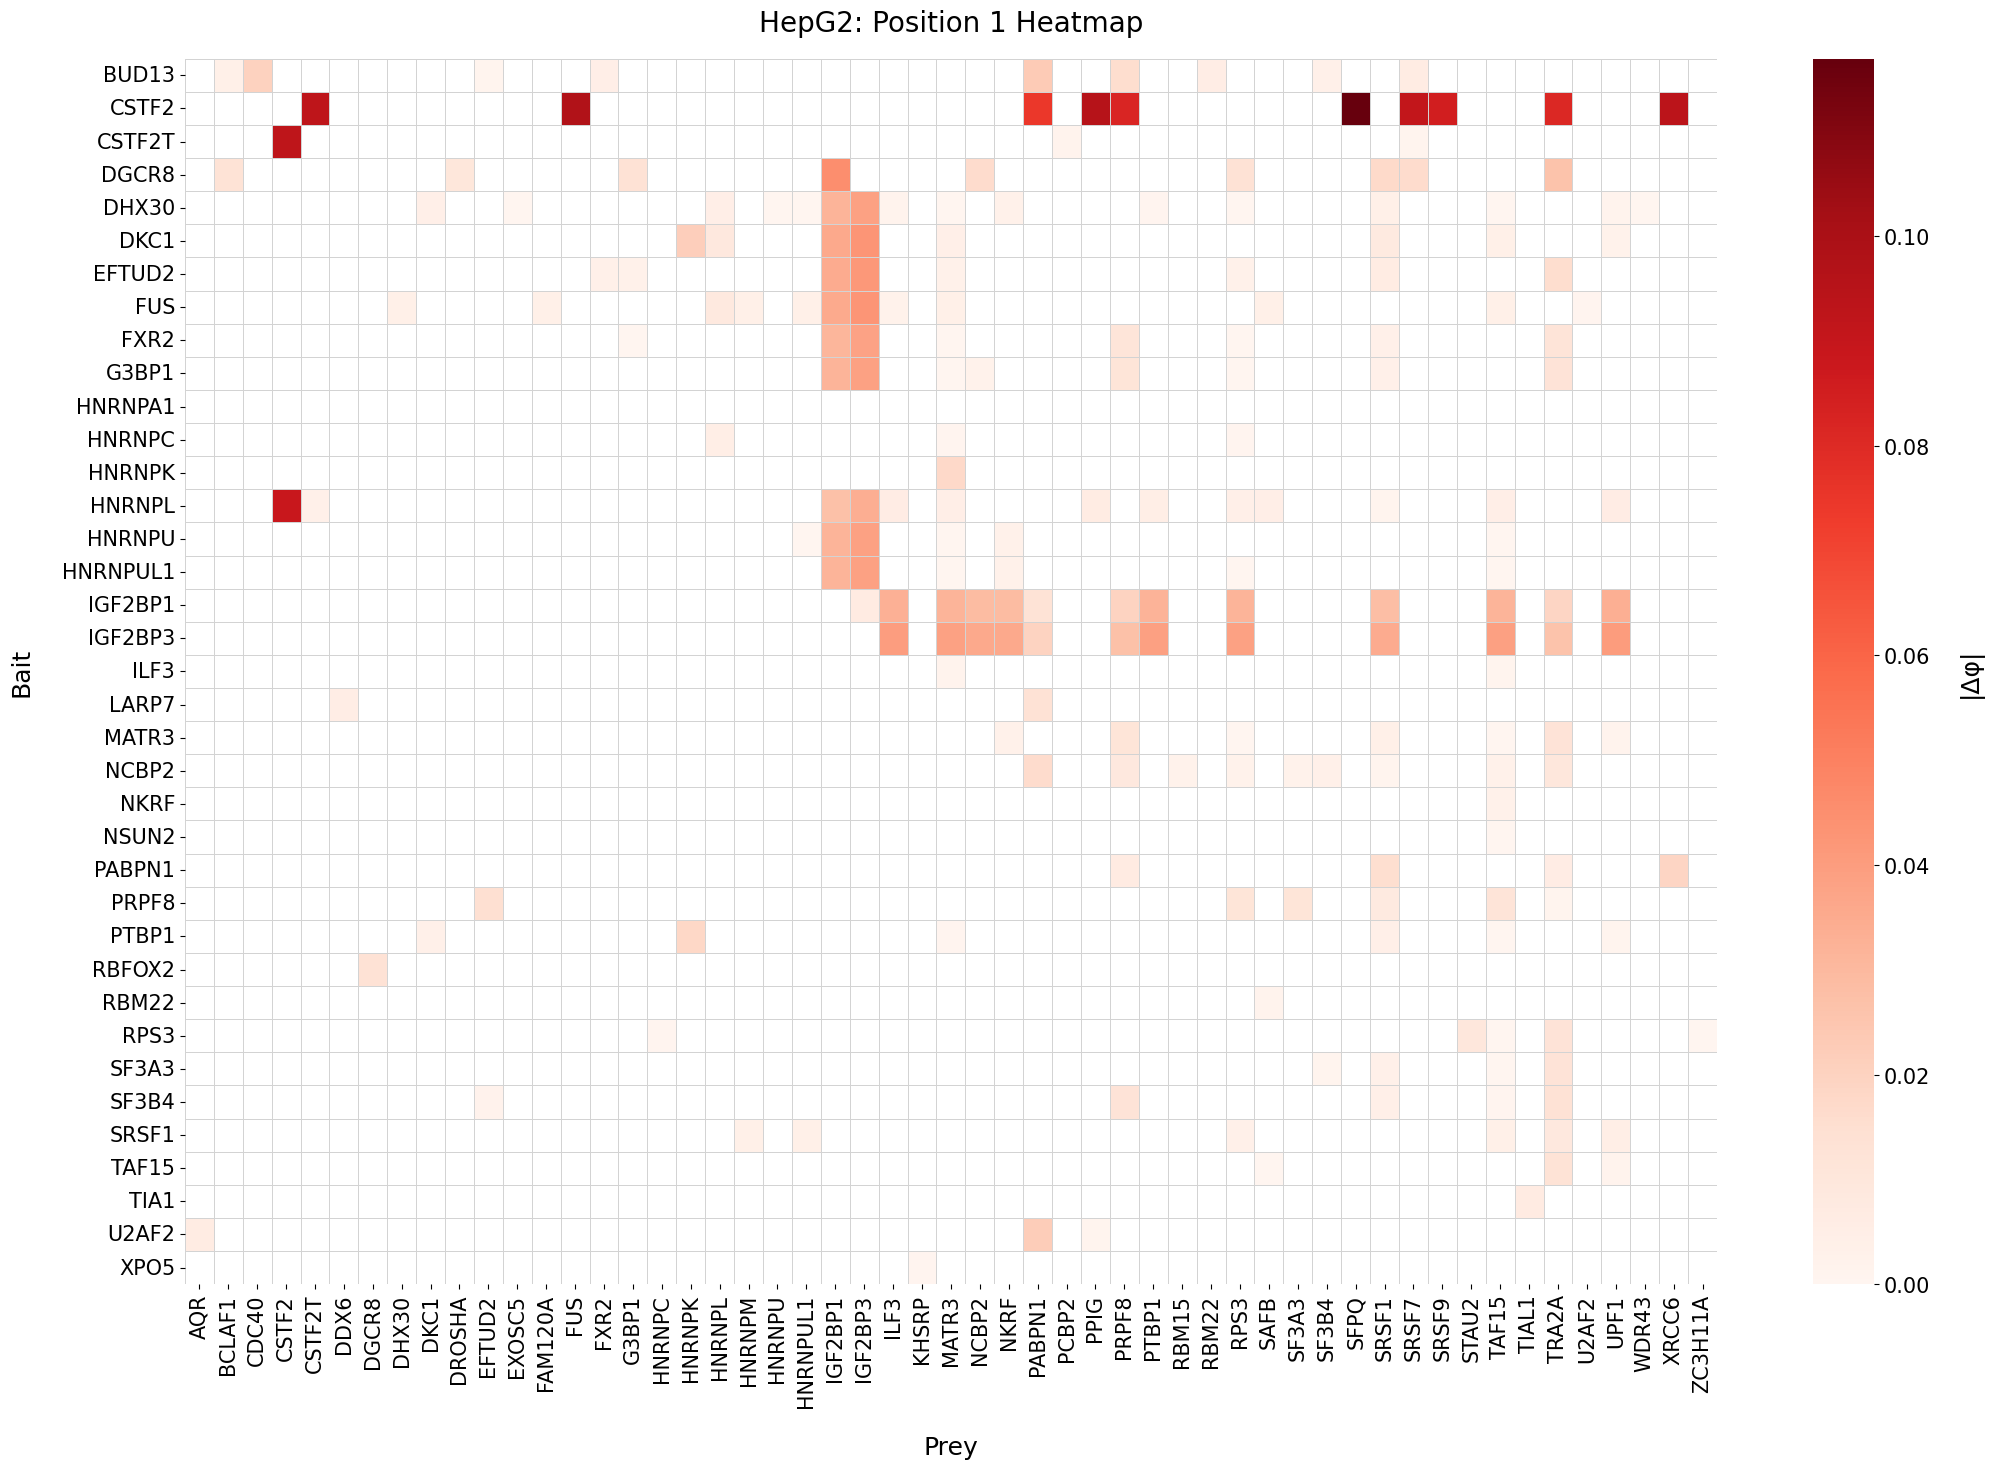

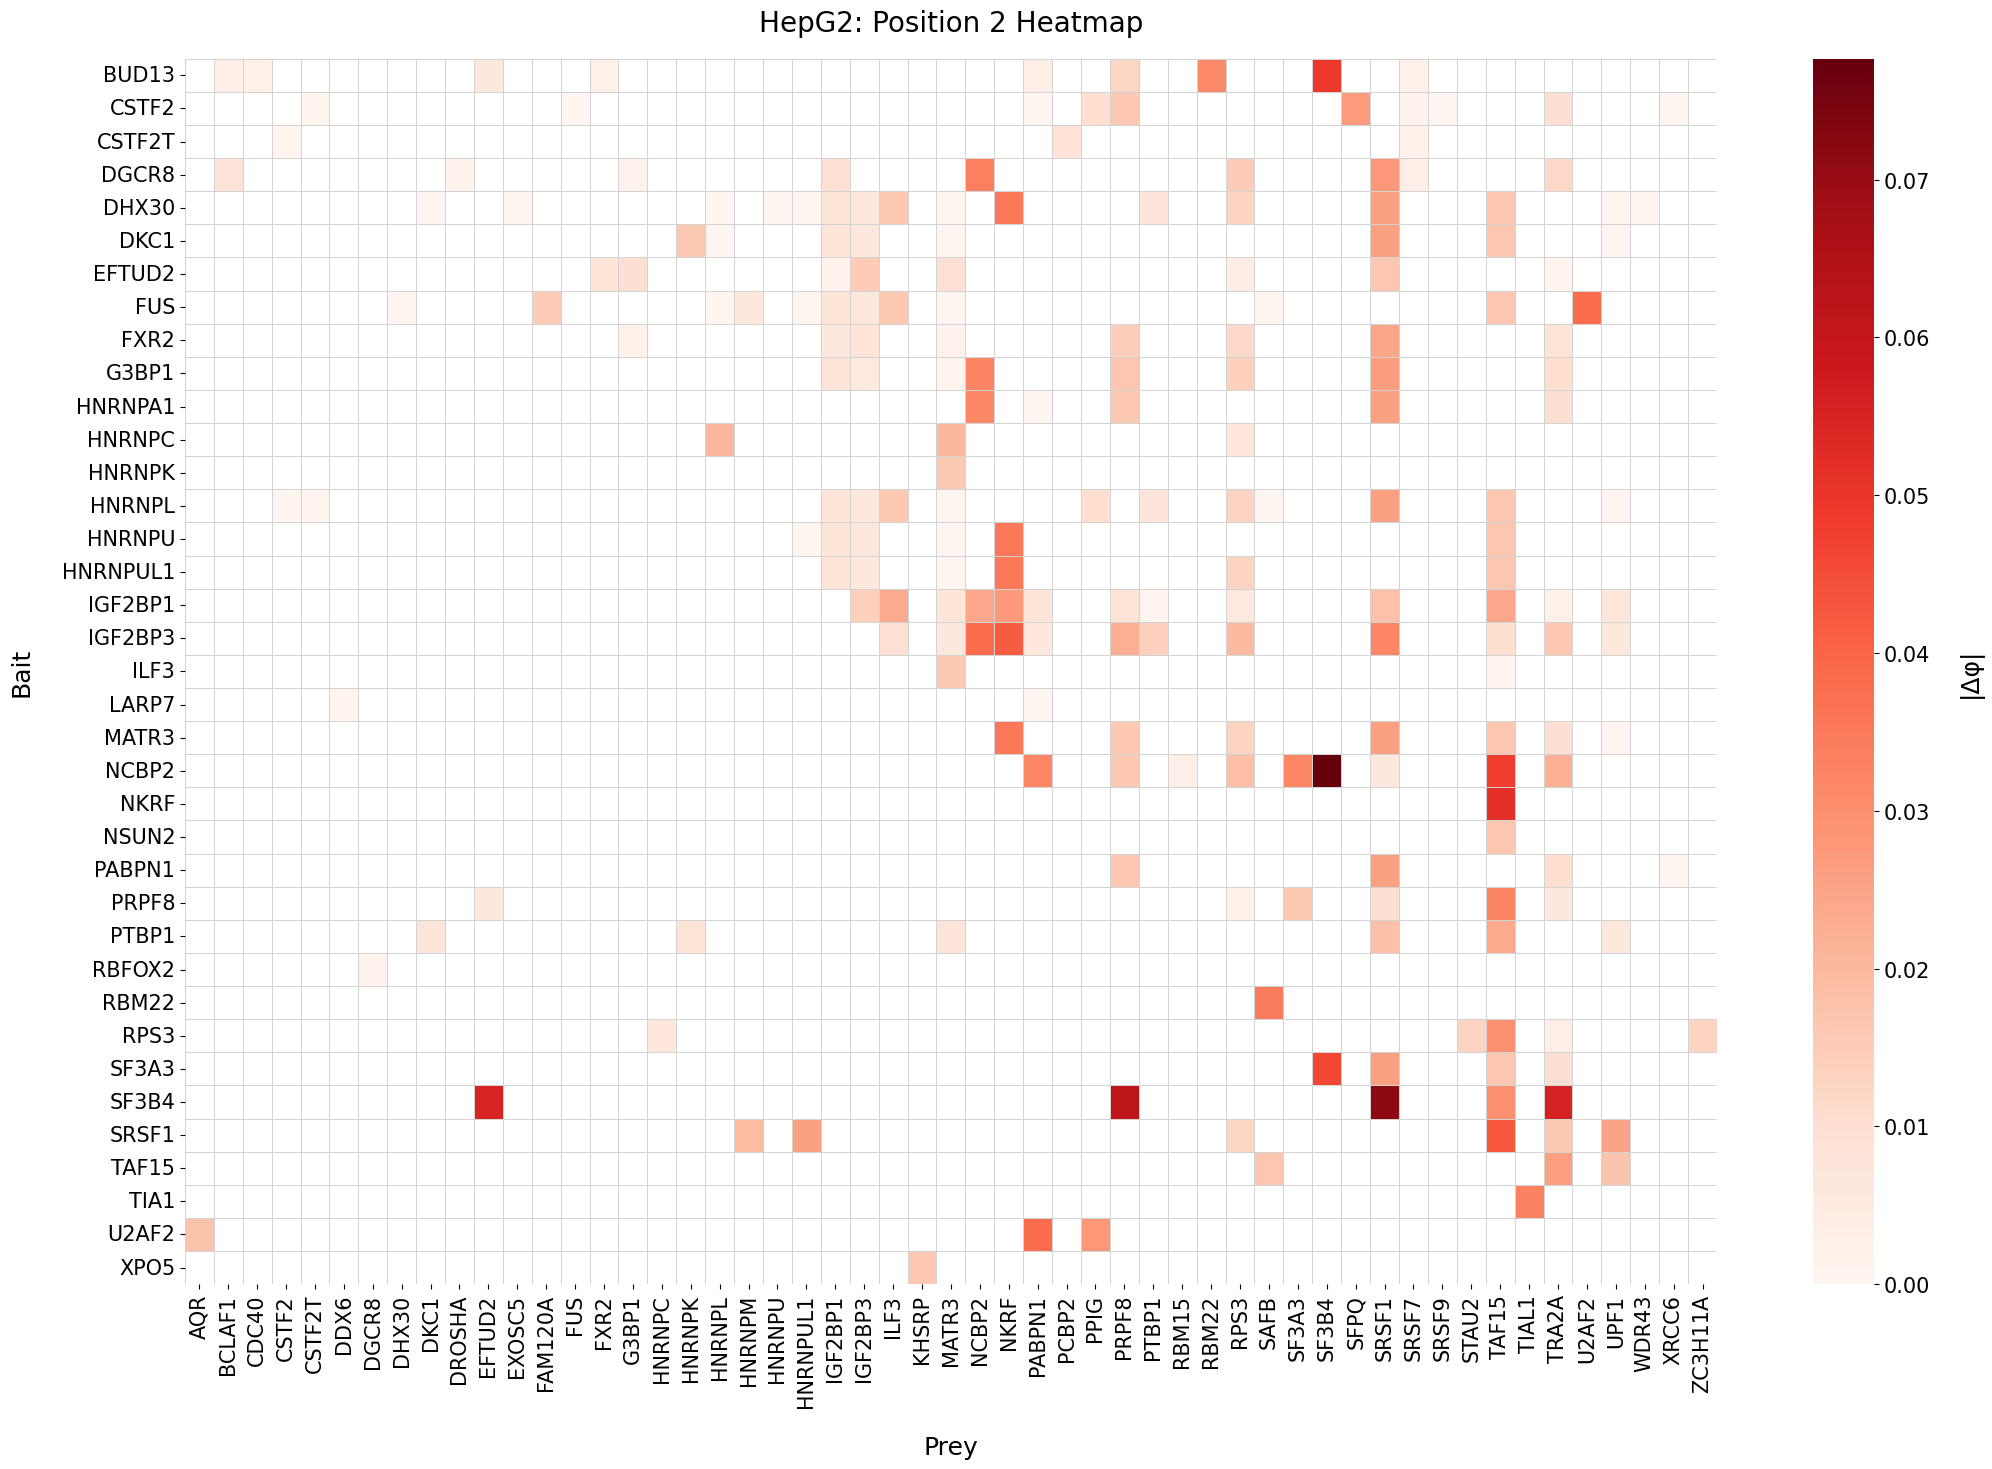

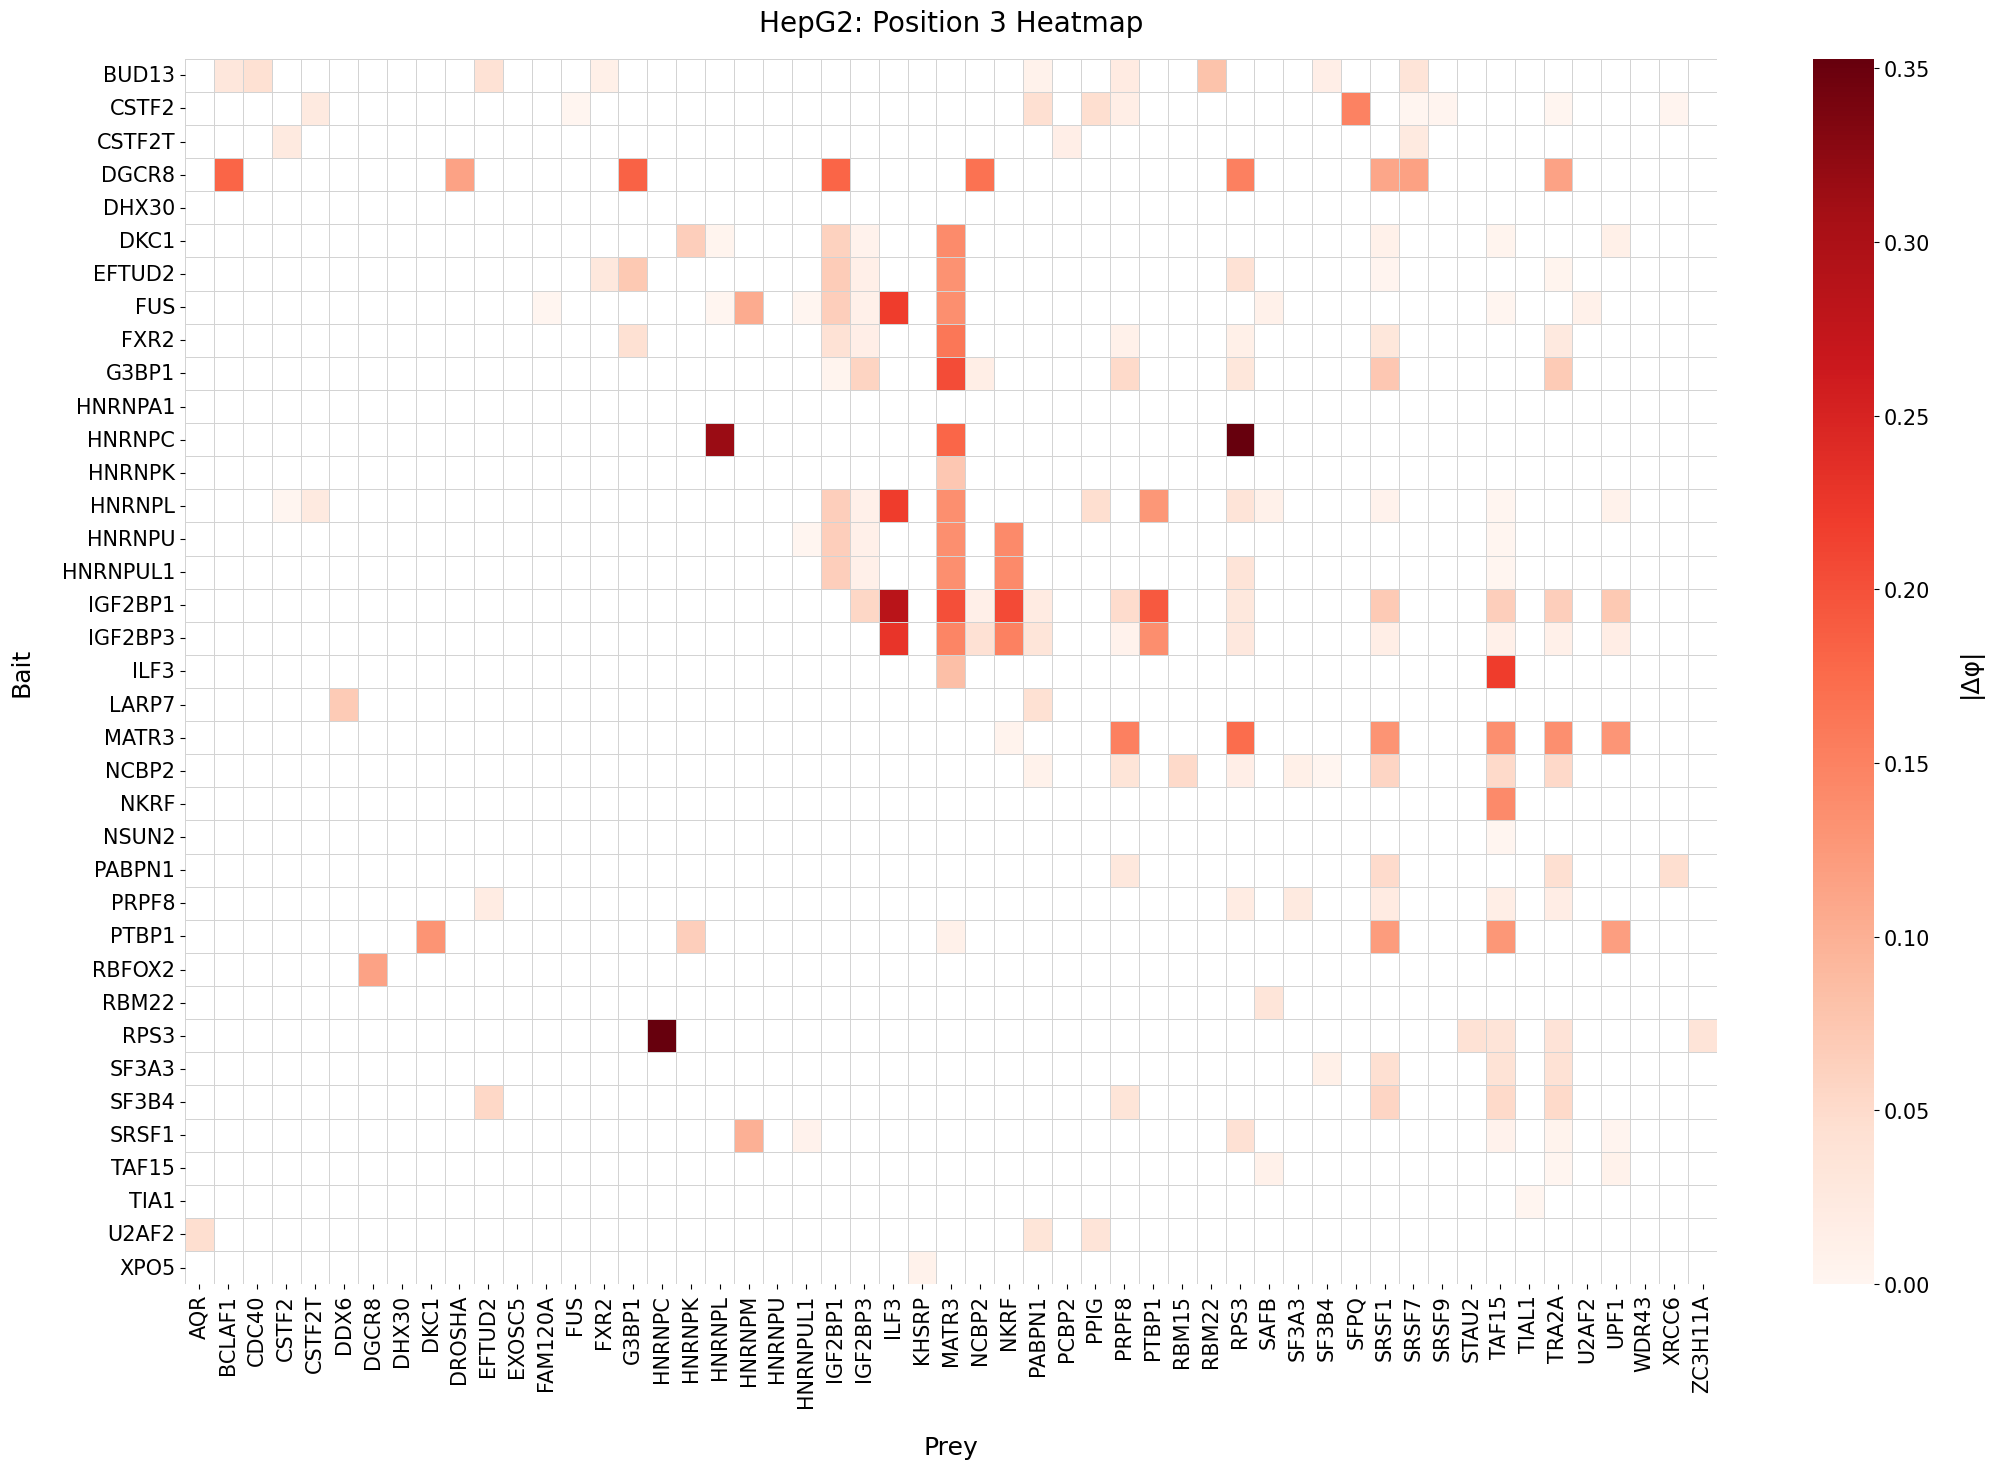

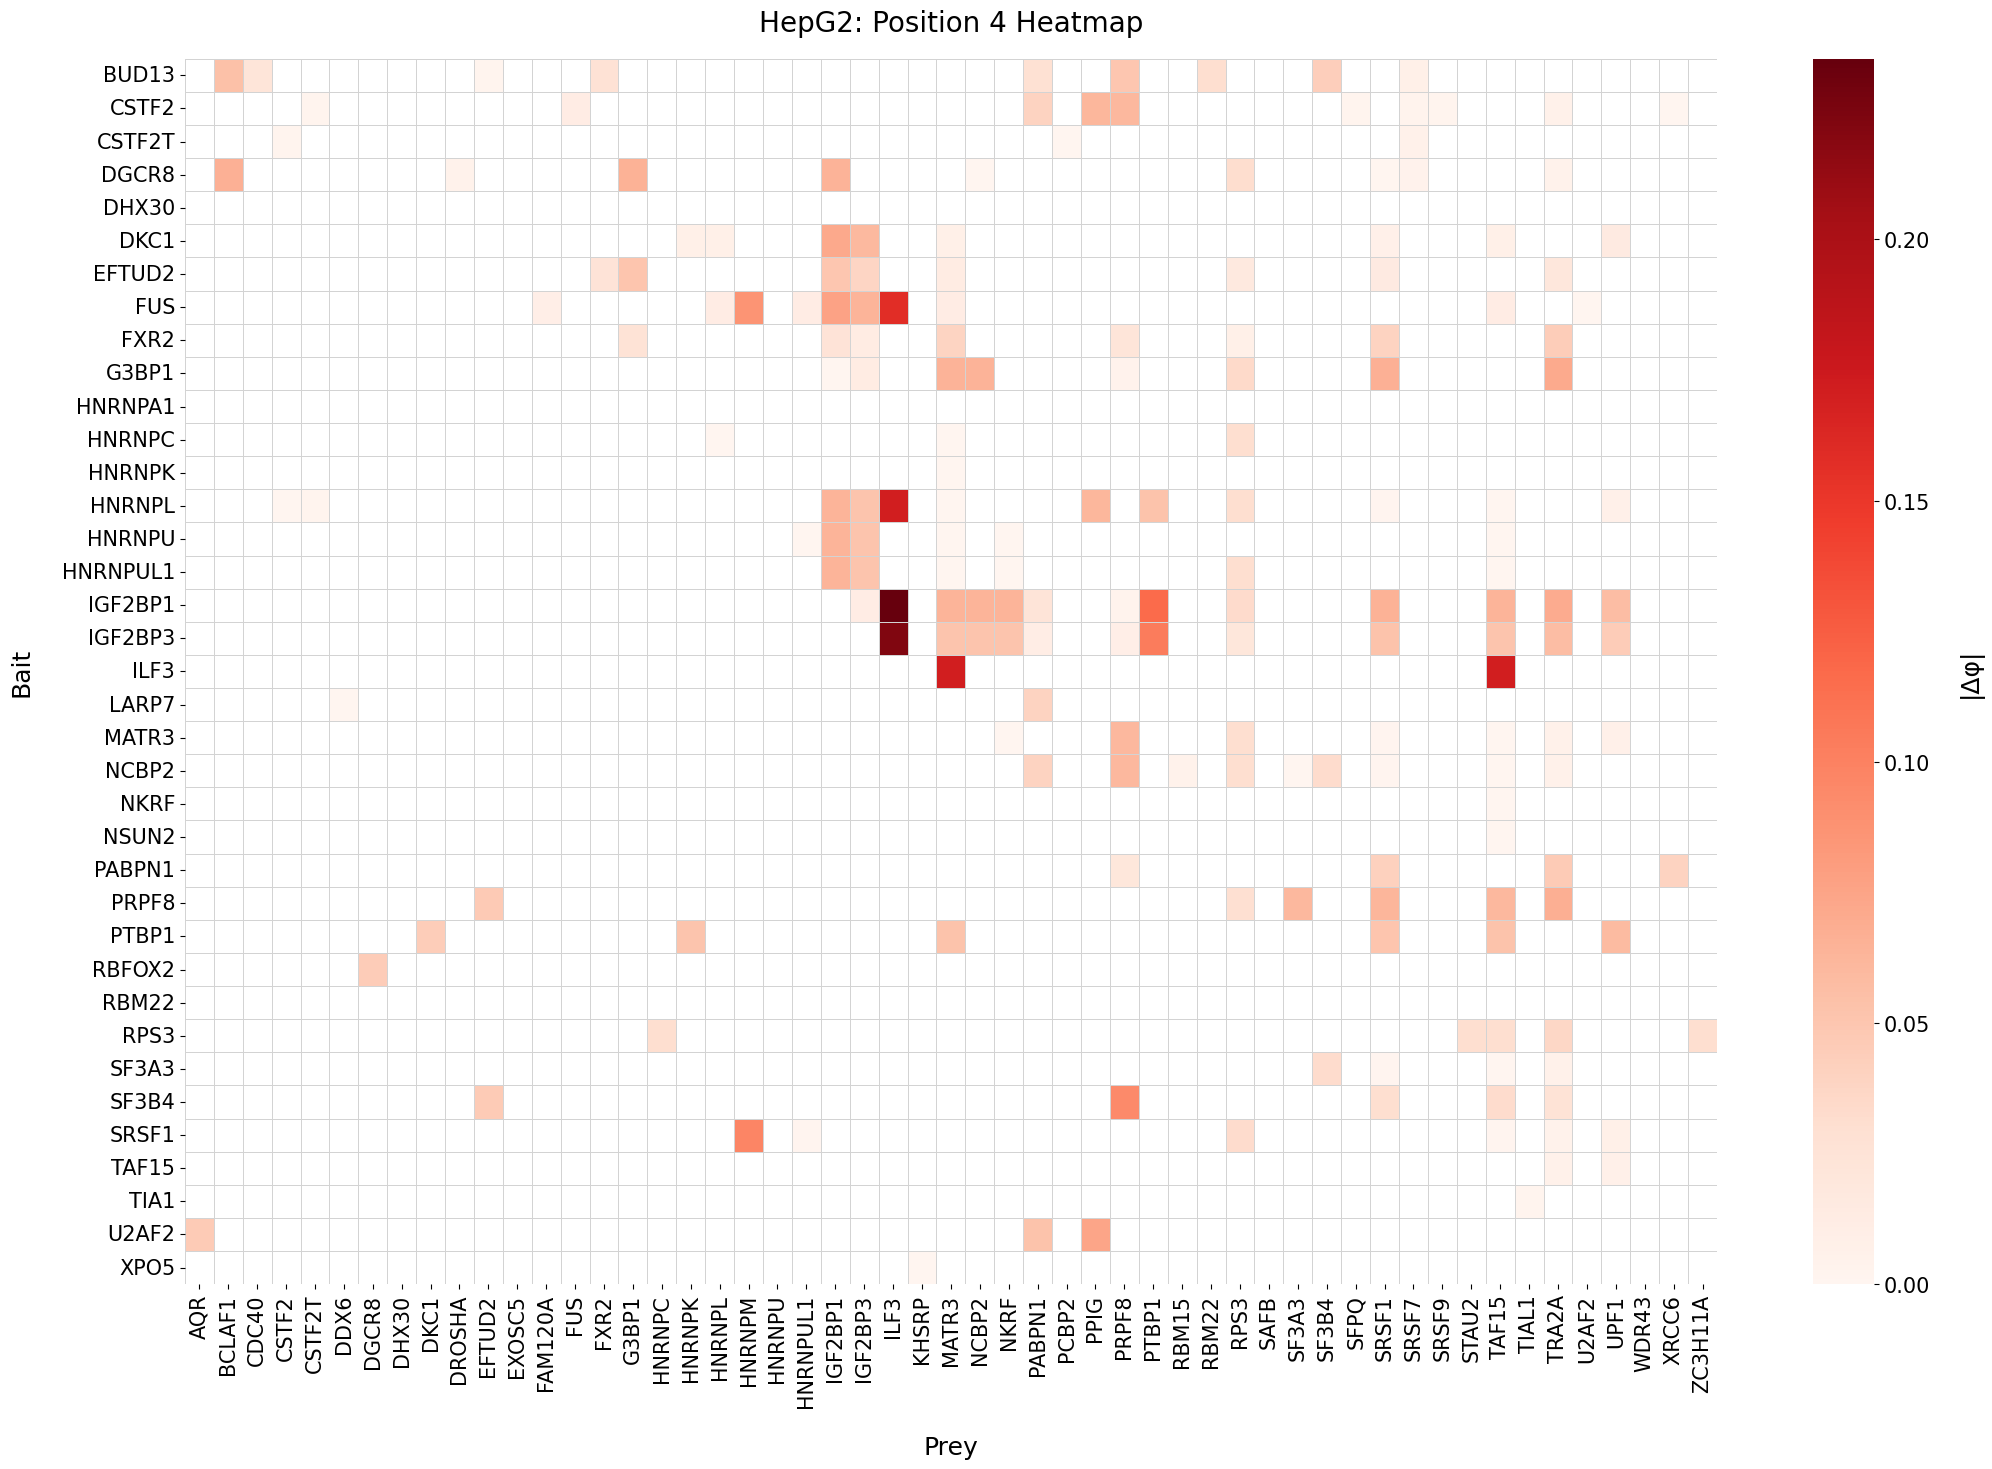

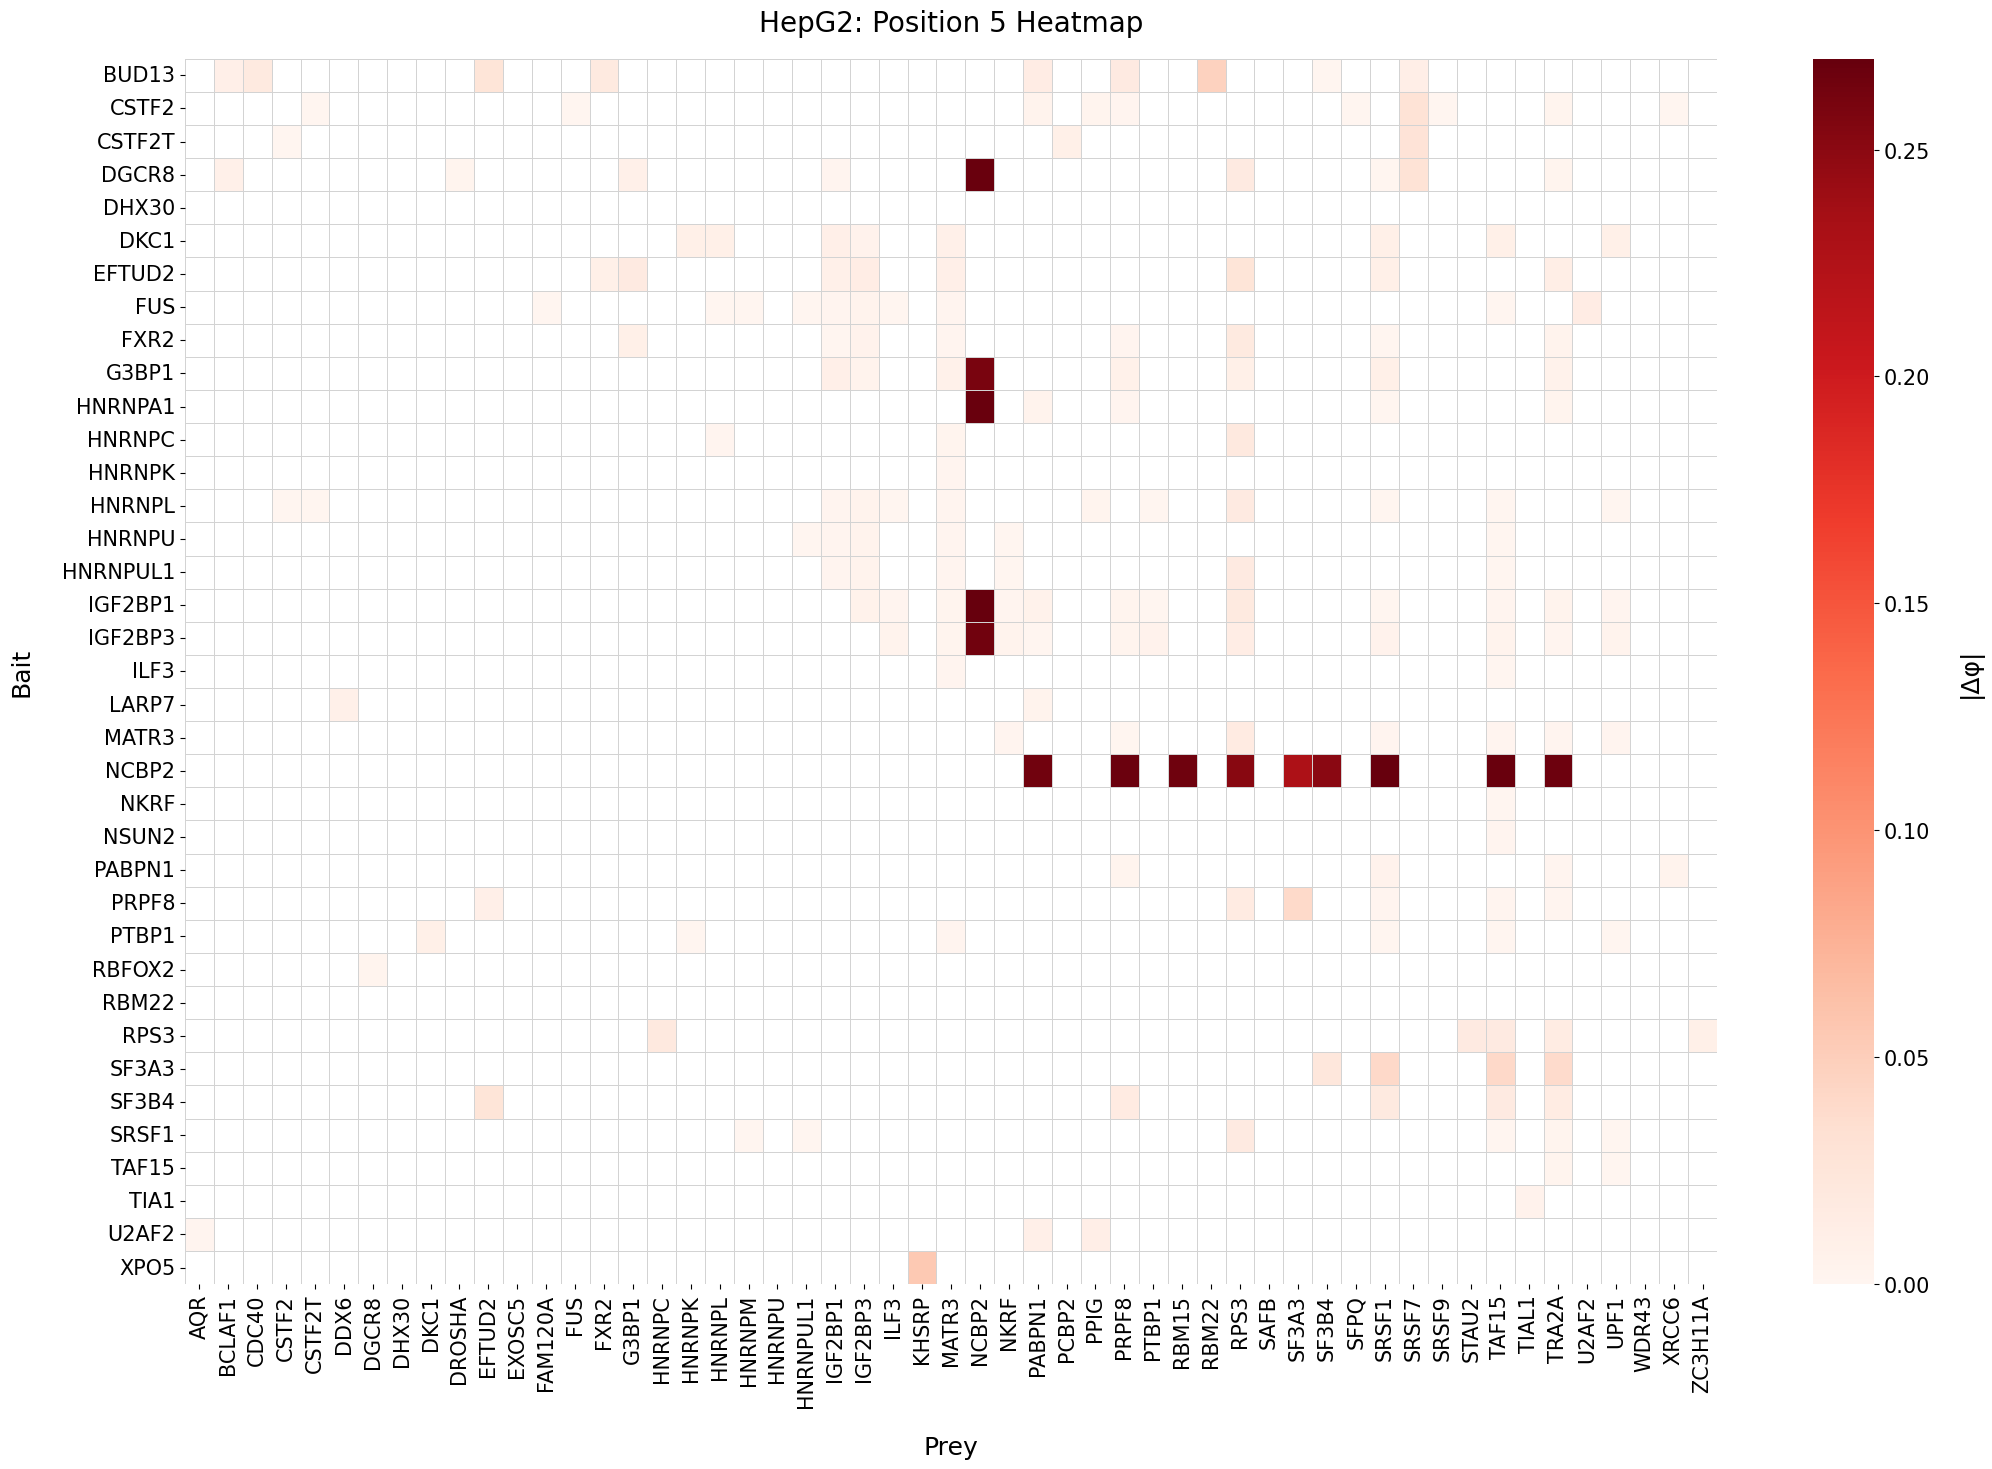

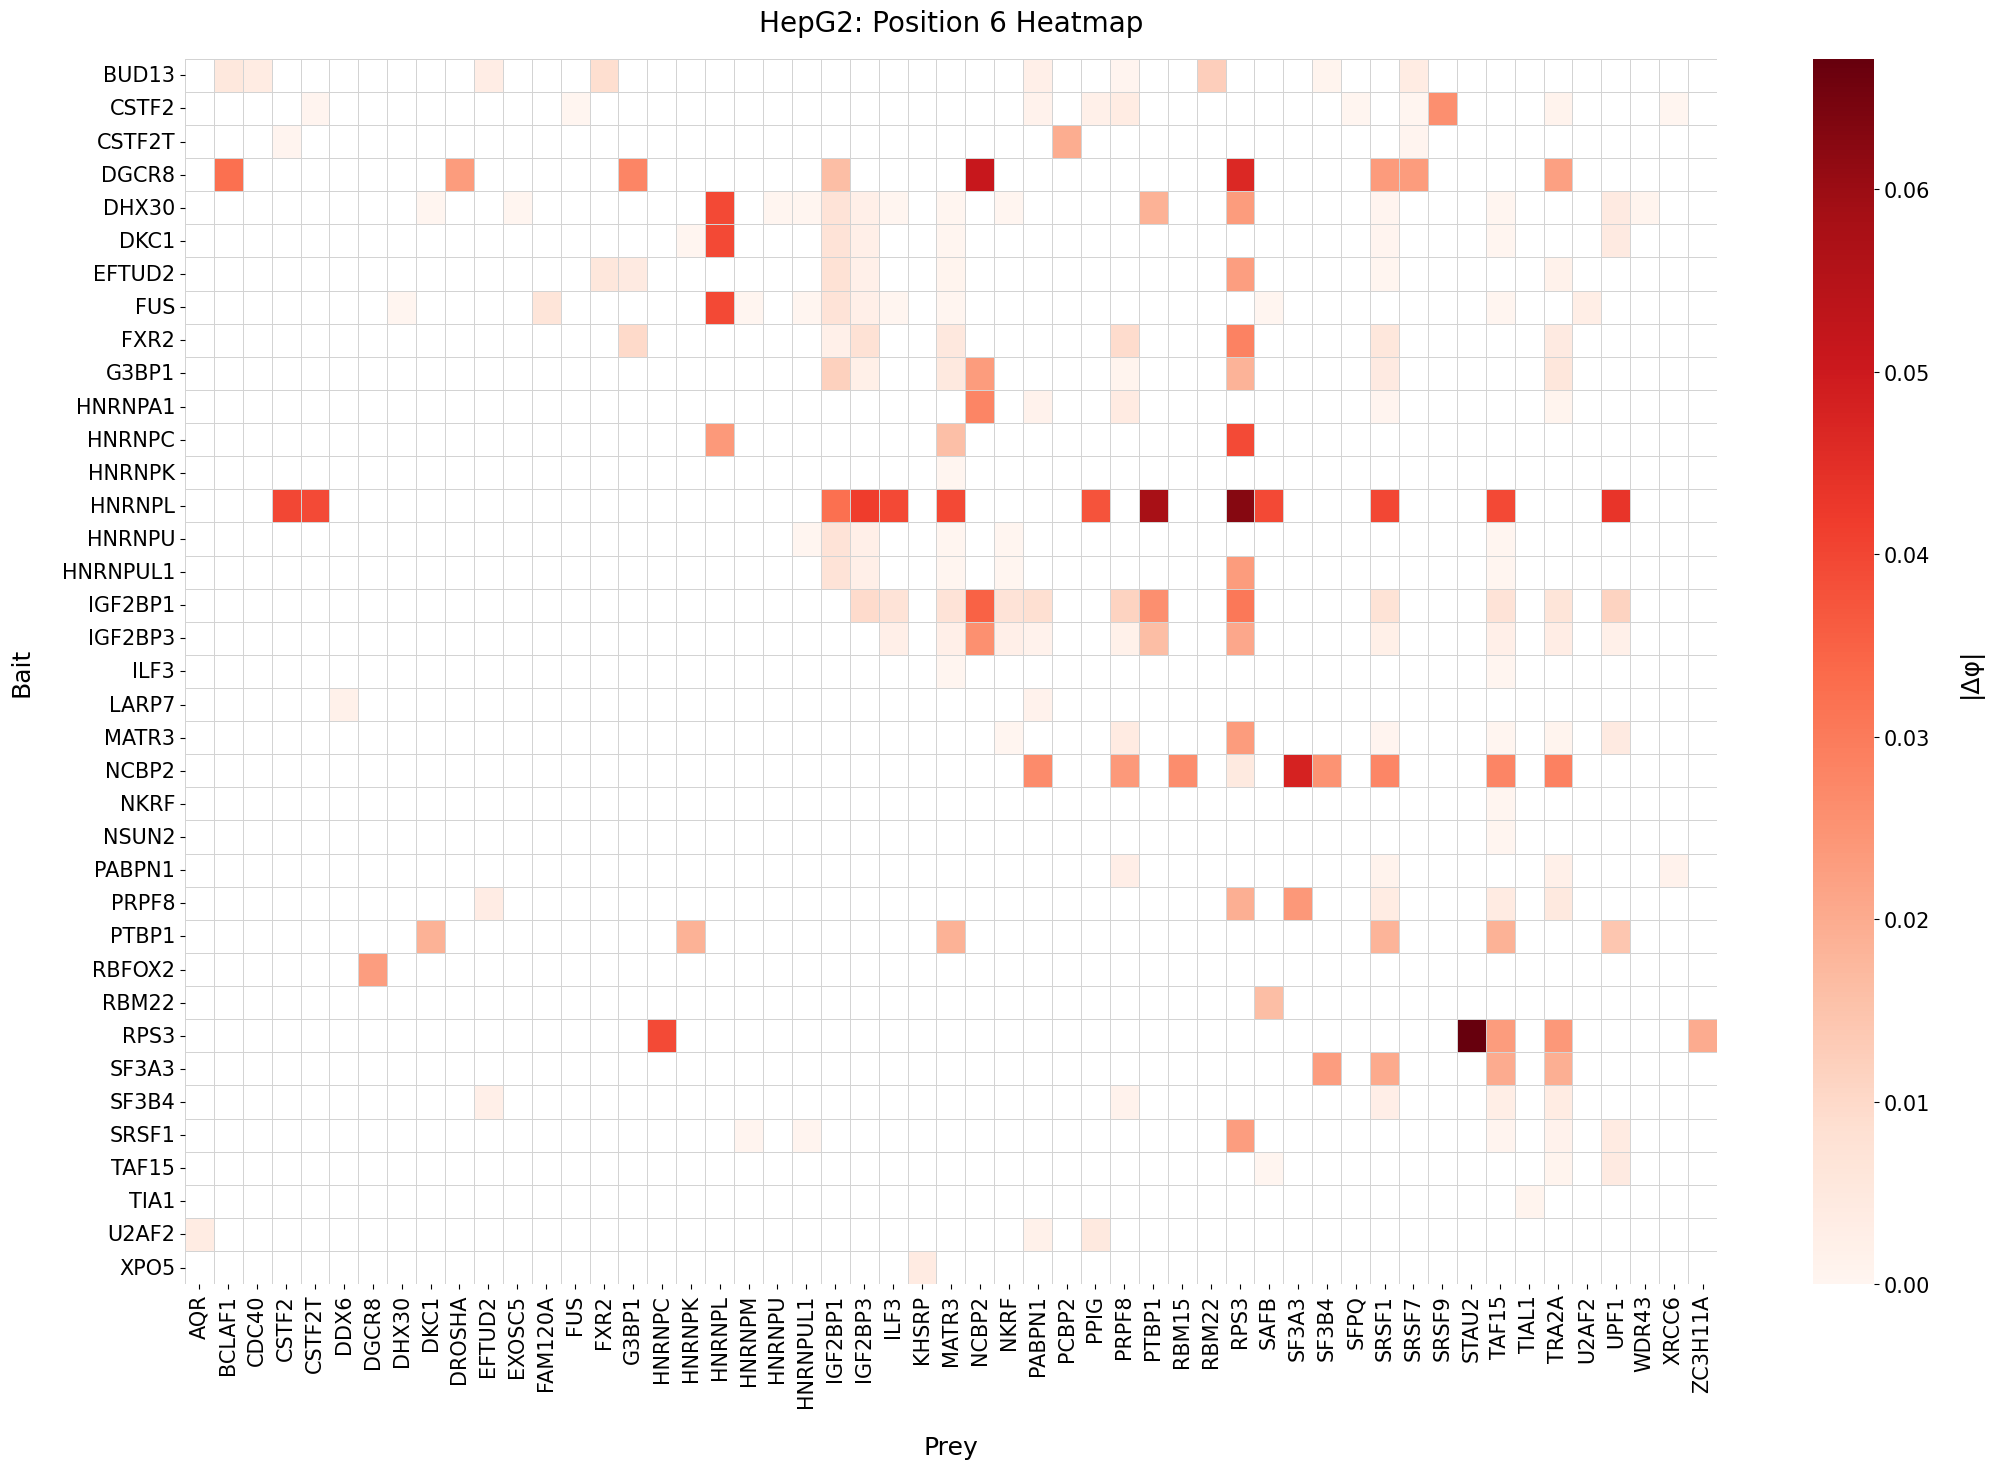

In [8]:
for i, each in enumerate(row_dfs2):
    # turn df into dict
    shap_dict = each.iloc[0].to_dict()  # {protein_name: shap_value}
    ppi_df_plot = ppi_df.copy()
    
    # Compute absolute difference
    ppi_df_plot['delta_shap'] = ppi_df_plot.apply(
        lambda row: abs(shap_dict[row['Bait']] - shap_dict[row['Prey']]), 
        axis=1)
    
    # Pivot into matrix (Prey = X, Bait = Y)
    heatmap_data = ppi_df_plot.pivot(index="Bait", columns="Prey", values="delta_shap")
    
    # Make figure scale with matrix size
    plt.figure(figsize=(len(heatmap_data.columns) * 0.4, len(heatmap_data.index) * 0.4))

    ax = sns.heatmap(
        heatmap_data,
        cmap="Reds",
        cbar_kws={"label": r"|Δφ|"},  # phi symbol
        linewidths=0.5,
        linecolor="lightgray",
        square=False,
        mask=heatmap_data.isna()  # keep NaN cells white
    )

    # Get colorbar and format its label/ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)          # tick labels
    cbar.ax.set_ylabel(r"|Δφ|", fontsize=18, labelpad=20)  # label

    # Axis labels with font size and labelpad
    plt.xlabel("Prey", fontsize=18, labelpad=20)
    plt.ylabel("Bait", fontsize=18, labelpad=20)

    # Tick labels
    plt.xticks(rotation=90, fontsize=15)
    plt.yticks(rotation=0, fontsize=15)

    # Title
    plt.title(f"HepG2: Position {i+1} Heatmap", fontsize=20, pad=20)

    plt.tight_layout()
    plt.show()
